# Truth Scaffold Dopamine Audit v001

This notebook performs structural analysis of the dopamine literature corpus using the Truth Scaffold framework.

Dataset:
dopamine_cleaned_TS_v001.csv

Fields:
- PMID
- title
- abstract
- year

No full-text articles are included.
1. Load dataset
2. Create text blob
3. Functional classification
4. Embedding generation
5. UMAP projection
6. Structural metrics
7. TS interpretation
8. Report export

The data and findings summarized in this audit are derived primarily from the titles and abstracts of the referenced publications. In accordance with established reporting standards, such as CONSORT for randomized trials and STROBE for observational studies, full research articles are expected to include comprehensive methodological and reporting details. These typically encompass participant demographics (e.g., age, sex/gender, ethnicity, socioeconomic factors), inclusion and exclusion criteria, study flow, prespecified primary and secondary outcomes, statistical analysis plans, handling of missing data, limitations, and, where appropriate, raw or unadjusted results.
Abstracts are not required to include this level of detail and often provide only a condensed summary of methods and findings. As a result, analyses based on abstract-level data are inherently limited by incomplete reporting. Any conclusions or critiques presented in this audit should be interpreted within this constraint.
The responsibility for complete, transparent, and reproducible reporting lies with study authors, journals, and the peer-review process. Where full-text articles were not accessed, this limitation is explicitly acknowledged.
Transparency helps science improve!


# ============================================
# LOAD PRECOMPUTED EMBEDDINGS / UMAP
# ============================================

# NOTE:
# Embeddings and UMAP coordinates were generated
# previously and frozen for reproducibility.
# Large-scale embedding generation (~157k records)
# is not rerun during standard audit execution.

embeddings = np.load(
    f"{BASE}\\dopamine_embeddings_TS_v001.npy"
)

umap_coords = np.load(
    f"{BASE}\\dopamine_umap_coords_v001.npy"
)

In [1]:
from pathlib import Path
import pandas as pd

BASE = Path(r"C:\neurofeedback_models\dopamine_20251202")

DATASET = BASE / "dopamine_cleaned_TS_v001.csv"

df = pd.read_csv(DATASET)

print("Loaded:", DATASET.name)
print("Rows:", len(df))
print(df.columns.tolist())

Loaded: dopamine_cleaned_TS_v001.csv
Rows: 157573
['pmid', 'title', 'abstract', 'year']


In [2]:
# --------------------------------------------------
# BUILD SEARCH TEXT
# --------------------------------------------------

df["text_blob"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

print(df["year"].min(), df["year"].max())

1960.0 2026.0


In [3]:
# --------------------------------------------------
# EARLY MONOAMINE / CATECHOLAMINE PAPERS
# --------------------------------------------------

monoamine_terms = [
    "monoamine",
    "catecholamine",
    "biogenic amine",
    "3-hydroxytyramine"
]

mask = df["text_blob"].apply(
    lambda x: any(term in x for term in monoamine_terms)
)

mono_df = (
    df[mask]
    .sort_values("year")
    [["year", "title"]]
)

print("Monoamine-related papers:")
print(mono_df.head(25))

Monoamine-related papers:
          year                                              title
16928   1960.0   Biological activity of 3-methoxy-catecholamines.
16805   1961.0  Excretion of dopamine in diseases of basal gan...
17430   1961.0  Some effects of a monoamine oxidase inhibitor ...
17099   1963.0     Dopamine: its occurrence in molluscan ganglia.
17226   1964.0  A COMPARISON OF PLATELET AGGREGATION PRODUCED ...
34083   1965.0  Brain Catecholamines: Relation to the Defense ...
129823  1965.0  Psychotropic drugs (2). Interaction between mo...
130453  1966.0  The synthesis of noradrenaline by isolated gui...
130449  1966.0  Micro-electrophoretic studies of neurones in t...
130485  1967.0  Temperature changes produced by the injection ...
129287  1967.0  The responses of thalamic neurons to iontophor...
130488  1967.0  Central temperature regulation in the consciou...
130482  1967.0  The inhibitory action of monoamines on lateral...
130481  1967.0  The content and localization of ca

In [4]:
# --------------------------------------------------
# EARLY MOTOR / MOVEMENT PAPERS
# --------------------------------------------------

motor_terms = [
    "motor",
    "movement",
    "parkinson",
    "rigidity",
    "tremor",
    "locomotion",
    "basal ganglia"
]

mask = df["text_blob"].apply(
    lambda x: any(term in x for term in motor_terms)
)

motor_df = (
    df[mask]
    .sort_values("year")
    [["year", "title"]]
)

print("Motor-related papers:")
print(motor_df.head(40))

Motor-related papers:
          year                                              title
16805   1961.0  Excretion of dopamine in diseases of basal gan...
16897   1961.0  Effect of dopamine on the isolated perfused lu...
17207   1964.0  ADMINISTRATION OF DIHYDROXYPHENYLALANINE TO PA...
129823  1965.0  Psychotropic drugs (2). Interaction between mo...
129391  1966.0  Neurochemical bases of tremor and other disord...
129779  1968.0  Histochemical fluorescence after application o...
130059  1969.0  Dopamine (3-hydroxytyramine) metabolism in par...
130067  1969.0              Action of dopamine on the human iris.
130056  1969.0  Antiparkinsonian drugs: inhibition of dopamine...
130053  1969.0  The metabolism of orally administered L-Dopa i...
130383  1969.0  Oral phenylalanine and tyrosine tolerance test...
129805  1969.0  L-dopa therapy in Parkinson's disease: a criti...
129839  1970.0  Effect of drugs used in psychoses on cerebral ...
130140  1970.0  Phenolic acid concentrations in the lu

In [5]:
# --------------------------------------------------
# REWARD / REINFORCEMENT EMERGENCE
# --------------------------------------------------

reward_terms = [
    "reward",
    "reinforcement",
    "pleasure",
    "motivation",
    "incentive"
]

mask = df["text_blob"].apply(
    lambda x: any(term in x for term in reward_terms)
)

reward_df = (
    df[mask]
    .sort_values("year")
    [["year", "title"]]
)

print("Reward-related papers:")
print(reward_df.head(40))

Reward-related papers:
          year                                              title
130376  1969.0  Facilitation of brain self-stimulation by cent...
129904  1972.0  Benzodiazepines: anxiety-reducing activity by ...
129636  1973.0  Dopaminergic and noradrenergic substrates of p...
129650  1973.0  Dopamine-beta-hydroxylase deficits in the brai...
129236  1973.0  Depressive disorders: toward a unified hypothe...
4962    1975.0     Catecholamines and drug-behavior interactions.
61519   1975.0               Biochemical research into psychosis.
8856    1975.0  Some effects of prenatal exposure to d-ampheta...
42435   1975.0  Attenuation of amphetamine-induced conditioned...
42434   1975.0  Influence of 6-hydroxydopamine injections in t...
6061    1975.0  Increased lever pressing for amphetamine after...
9820    1975.0  Effects of intraventricular 6-hydroxydopamine ...
29167   1975.0  Noradrenergic role in the self-administration ...
8218    1975.0  Neurochemical changes associated with

In [6]:
# --------------------------------------------------
# SEMANTIC DOMAINS
# --------------------------------------------------

semantic_domains = {
    "receptor": [
        "receptor",
        "dopamine receptor",
        "d1 receptor",
        "d2 receptor"
    ],

    "reward": [
        "reward",
        "reinforcement",
        "pleasure"
    ],

    "motivation": [
        "motivation",
        "motivated",
        "incentive"
    ],

    "cognition": [
        "cognition",
        "cognitive",
        "executive function",
        "attention",
        "working memory"
    ],

    "motor": [
        "motor",
        "movement",
        "parkinson",
        "locomotion",
        "rigidity",
        "tremor"
    ]
}

In [7]:
# --------------------------------------------------
# REPAIR YEAR + RUN EARLIEST DOMAIN EXTRACTION
# --------------------------------------------------

import pandas as pd
import numpy as np

# rebuild text blob if needed
df["text_blob"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# create numeric year safely
df["year_num"] = pd.to_numeric(
    df["year"].astype(str).str[:4],
    errors="coerce"
)

print("Year range:", df["year_num"].min(), "to", df["year_num"].max())

results = []

for domain, terms in semantic_domains.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    subset = (
        df.loc[mask, ["year_num", "title"]]
        .dropna(subset=["year_num"])
        .sort_values("year_num")
        .head(15)
    )

    print("\n" + "="*60)
    print(domain.upper())
    print("="*60)
    print(subset.to_string(index=False))

    results.append({
        "domain": domain,
        "earliest_year": subset["year_num"].min() if len(subset) else np.nan,
        "n_hits": int(mask.sum())
    })

timeline_df = pd.DataFrame(results).sort_values("earliest_year")

print("\n\n=== SEMANTIC EMERGENCE TIMELINE ===")
print(timeline_df.to_string(index=False))

Year range: 1960 to 2026

RECEPTOR
 year_num                                                                                                                                        title
     1962                                          Effect of sympathomimetic amines on the blocking action of guanethidine, bretylium and xylocholine.
     1964                            THE EFFECTS OF ADRENALINE AND OTHER DRUGS AFFECTING CARBOHYDRATE METABOLISM ON CONTRACTIONS OF THE RAT DIAPHRAGM.
     1965                                         Psychotropic drugs (2). Interaction between monoamine oxidase (MAO) inhibitors and other substances.
     1967 Temperature changes produced by the injection of catecholamines and 5-hydroxytryptamine into the cerebral ventricles of the conscious mouse.
     1967                                                                   The responses of thalamic neurons to iontophoretically applied monoamines.
     1968                                               Evi

In [8]:
# --------------------------------------------------
# DECADE VARIABLE
# --------------------------------------------------

df["year_num"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

df = df.dropna(subset=["year_num"])

df["decade"] = (
    (df["year_num"] // 10) * 10
).astype(int)

print(df["decade"].value_counts().sort_index())

decade
1960       86
1970     5120
1980    20845
1990    29017
2000    33557
2010    41695
2020    27253
Name: count, dtype: int64


In [9]:
# --------------------------------------------------
# SEMANTIC DOMAIN COUNTS BY DECADE
# --------------------------------------------------

trend_results = []

for domain, terms in semantic_domains.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    temp = df[mask].groupby("decade").size()

    for decade, count in temp.items():

        trend_results.append({
            "domain": domain,
            "decade": decade,
            "count": count
        })

trend_df = pd.DataFrame(trend_results)

print(trend_df.head())

     domain  decade  count
0  receptor    1960      9
1  receptor    1970   1235
2  receptor    1980   7168
3  receptor    1990  12583
4  receptor    2000  14266


In [10]:
# --------------------------------------------------
# NORMALIZE BY TOTAL PAPERS PER DECADE
# --------------------------------------------------

total_by_decade = (
    df.groupby("decade")
      .size()
      .rename("total_papers")
)

trend_df = trend_df.merge(
    total_by_decade,
    on="decade"
)

trend_df["rate"] = (
    trend_df["count"] /
    trend_df["total_papers"]
)

print(trend_df.head())

     domain  decade  count  total_papers      rate
0  receptor    1960      9            86  0.104651
1  receptor    1970   1235          5120  0.241211
2  receptor    1980   7168         20845  0.343871
3  receptor    1990  12583         29017  0.433642
4  receptor    2000  14266         33557  0.425127


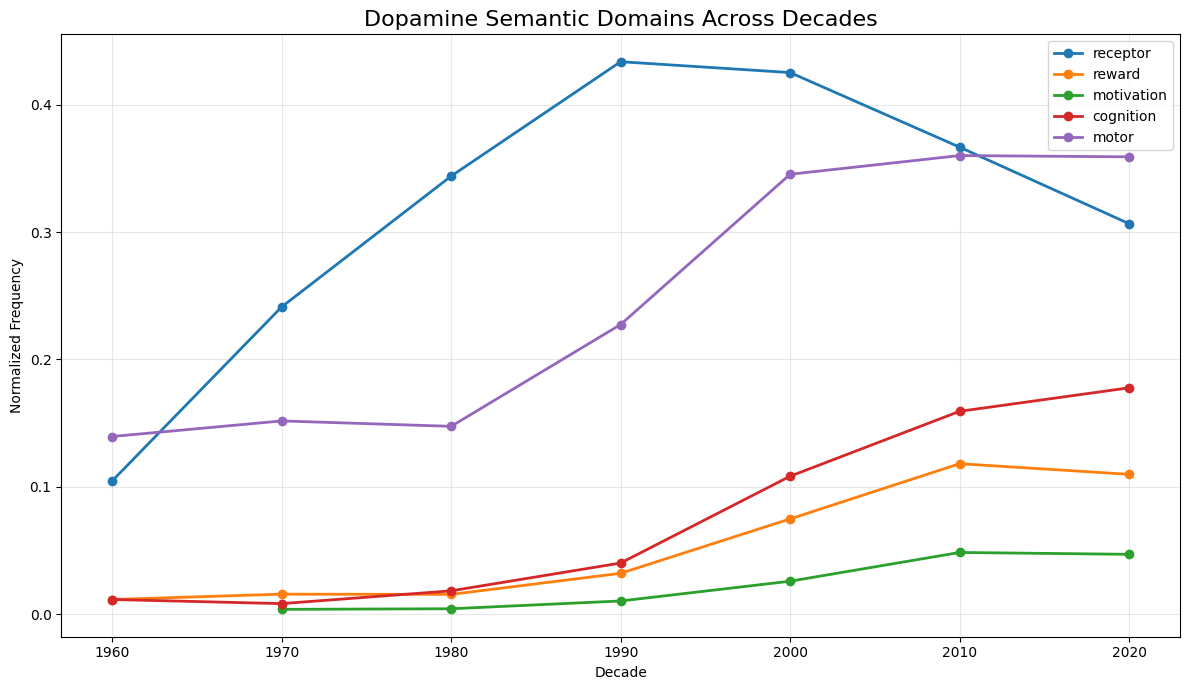

In [11]:
# --------------------------------------------------
# PLOT SEMANTIC TRENDS
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

for domain in trend_df["domain"].unique():

    sub = trend_df[
        trend_df["domain"] == domain
    ]

    plt.plot(
        sub["decade"],
        sub["rate"],
        marker="o",
        linewidth=2,
        label=domain
    )

plt.title(
    "Dopamine Semantic Domains Across Decades",
    fontsize=16
)

plt.xlabel("Decade")
plt.ylabel("Normalized Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# --------------------------------------------------
# SAVE TREND DATA
# --------------------------------------------------

trend_df.to_csv(
    BASE / "dopamine_semantic_trends.csv",
    index=False
)

print("Saved:")
print(BASE / "dopamine_semantic_trends.csv")

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_semantic_trends.csv


In [13]:
# --------------------------------------------------
# DISORDER DOMAINS
# --------------------------------------------------

disorder_domains = {

    "parkinsons": [
        "parkinson",
        "parkinsonism"
    ],

    "schizophrenia": [
        "schizophrenia",
        "schizophrenic",
        "psychosis"
    ],

    "adhd": [
        "adhd",
        "attention deficit",
        "hyperactivity",
        "hyperkinetic"
    ],

    "addiction": [
        "addiction",
        "substance use",
        "drug abuse",
        "dependence",
        "reward"
    ],

    "depression": [
        "depression",
        "depressive disorder"
    ],

    "ocd": [
        "obsessive compulsive",
        "ocd"
    ],

    "bipolar": [
        "bipolar",
        "mania",
        "manic depressive"
    ]
}

In [14]:
# --------------------------------------------------
# EARLIEST DOPAMINE-DISORDER PAPERS
# --------------------------------------------------

disorder_results = []

for disorder, terms in disorder_domains.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    subset = (
        df.loc[mask, ["year_num", "title"]]
        .dropna()
        .sort_values("year_num")
        .head(20)
    )

    print("\n" + "="*70)
    print(disorder.upper())
    print("="*70)

    print(subset.to_string(index=False))

    disorder_results.append({
        "disorder": disorder,
        "earliest_year": subset["year_num"].min(),
        "n_hits": int(mask.sum())
    })

disorder_timeline = (
    pd.DataFrame(disorder_results)
    .sort_values("earliest_year")
)

print("\n\n=== DISORDER ATTACHMENT TIMELINE ===")
print(disorder_timeline.to_string(index=False))


PARKINSONS
 year_num                                                                                                                   title
   1961.0                                                                     Excretion of dopamine in diseases of basal ganglia.
   1964.0                                                      ADMINISTRATION OF DIHYDROXYPHENYLALANINE TO PARKINSONIAN PATIENTS.
   1965.0                    Psychotropic drugs (2). Interaction between monoamine oxidase (MAO) inhibitors and other substances.
   1969.0                                                           The metabolism of orally administered L-Dopa in Parkinsonism.
   1969.0                                                                                   Action of dopamine on the human iris.
   1969.0                                               Oral phenylalanine and tyrosine tolerance tests in Parkinsonian patients.
   1969.0         Antiparkinsonian drugs: inhibition of dopamine uptake in the

In [15]:
# --------------------------------------------------
# DISORDER TRENDS BY DECADE
# --------------------------------------------------

disorder_trends = []

for disorder, terms in disorder_domains.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    temp = (
        df[mask]
        .groupby("decade")
        .size()
    )

    for decade, count in temp.items():

        disorder_trends.append({
            "disorder": disorder,
            "decade": decade,
            "count": count
        })

disorder_trend_df = pd.DataFrame(disorder_trends)

print(disorder_trend_df.head())

     disorder  decade  count
0  parkinsons    1960      9
1  parkinsons    1970    246
2  parkinsons    1980    972
3  parkinsons    1990   3190
4  parkinsons    2000   7270


In [16]:
# --------------------------------------------------
# NORMALIZE BY TOTAL DOPAMINE PAPERS
# --------------------------------------------------

total_by_decade = (
    df.groupby("decade")
      .size()
      .rename("total_papers")
)

disorder_trend_df = disorder_trend_df.merge(
    total_by_decade,
    on="decade"
)

disorder_trend_df["rate"] = (
    disorder_trend_df["count"] /
    disorder_trend_df["total_papers"]
)

print(disorder_trend_df.head())

     disorder  decade  count  total_papers      rate
0  parkinsons    1960      9            86  0.104651
1  parkinsons    1970    246          5120  0.048047
2  parkinsons    1980    972         20845  0.046630
3  parkinsons    1990   3190         29017  0.109936
4  parkinsons    2000   7270         33557  0.216646


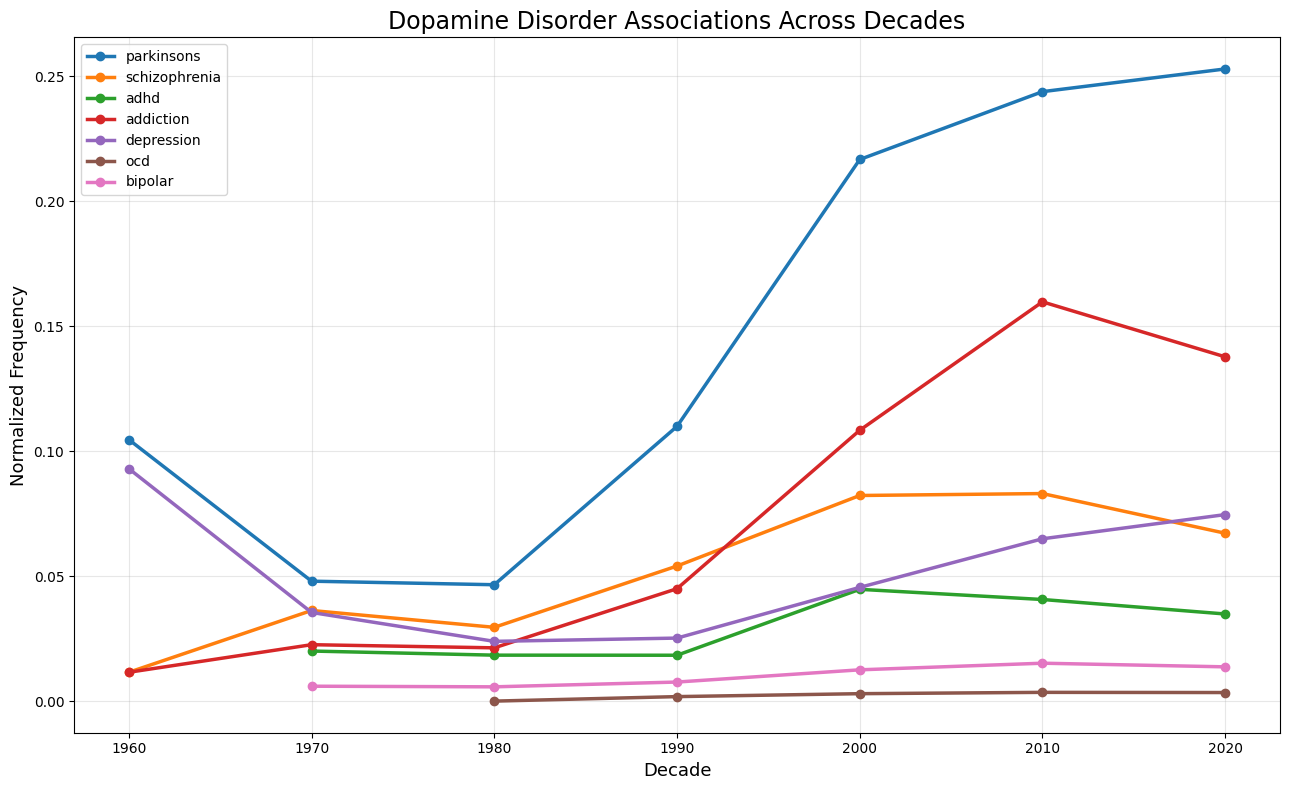

In [17]:
# --------------------------------------------------
# PLOT DISORDER EXPANSION
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(13,8))

for disorder in disorder_trend_df["disorder"].unique():

    sub = disorder_trend_df[
        disorder_trend_df["disorder"] == disorder
    ]

    plt.plot(
        sub["decade"],
        sub["rate"],
        marker="o",
        linewidth=2.5,
        label=disorder
    )

plt.title(
    "Dopamine Disorder Associations Across Decades",
    fontsize=17
)

plt.xlabel("Decade", fontsize=13)
plt.ylabel("Normalized Frequency", fontsize=13)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# --------------------------------------------------
# SAVE RESULTS
# --------------------------------------------------

OUT = BASE / "dopamine_disorder_trends.csv"

disorder_trend_df.to_csv(
    OUT,
    index=False
)

print("Saved:")
print(OUT)

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_disorder_trends.csv


In [19]:
# --------------------------------------------------
# CHEMICAL TRUNK CORE TERMS
# --------------------------------------------------

chemical_trunk = {
    "phenylalanine": [
        "phenylalanine"
    ],
    "tyrosine": [
        "tyrosine"
    ],
    "l_dopa": [
        "l-dopa", "levodopa", "dihydroxyphenylalanine", "dopa"
    ],
    "dopamine": [
        "dopamine", "3-hydroxytyramine"
    ],
    "norepinephrine": [
        "norepinephrine", "noradrenaline"
    ],
    "epinephrine": [
        "epinephrine", "adrenaline"
    ],
    "phenethylamine": [
        "phenethylamine", "phenylethylamine", "pea"
    ],
    "tyramine": [
        "tyramine"
    ],
    "tryptophan": [
        "tryptophan"
    ],
    "tryptamine": [
        "tryptamine"
    ],
    "serotonin": [
        "serotonin", "5-hydroxytryptamine", "5-ht"
    ],
    "catecholamine": [
        "catecholamine", "catecholamines"
    ],
    "monoamine": [
        "monoamine", "monoamines", "biogenic amine", "biogenic amines"
    ]
}

In [20]:
# --------------------------------------------------
# EARLIEST CHEMICAL TRUNK APPEARANCES
# --------------------------------------------------

trunk_results = []

for chem, terms in chemical_trunk.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    subset = (
        df.loc[mask, ["year_num", "title"]]
        .dropna()
        .sort_values("year_num")
        .head(12)
    )

    print("\n" + "="*70)
    print(chem.upper())
    print("="*70)
    print(subset.to_string(index=False))

    trunk_results.append({
        "chemical": chem,
        "earliest_year": subset["year_num"].min() if len(subset) else np.nan,
        "n_hits": int(mask.sum())
    })

trunk_timeline = (
    pd.DataFrame(trunk_results)
    .sort_values("earliest_year")
)

print("\n\n=== CHEMICAL TRUNK TIMELINE ===")
print(trunk_timeline.to_string(index=False))


PHENYLALANINE
 year_num                                                                                                                        title
   1960.0                            The effect of precursors of noradrenalin on the response to tyramine and sympathetic stimulation.
   1963.0                                          NOREPINEPHRINE AND 3,4DIHYDROXYPHENETHYLAMINE TURNOVER IN GUINEA PIG BRAIN IN VIVO.
   1964.0                                                                                         SCLEROTIZATION IN THE BLOWFLY IMAGO.
   1964.0                                                           ADMINISTRATION OF DIHYDROXYPHENYLALANINE TO PARKINSONIAN PATIENTS.
   1966.0                                                                 The synthesis of noradrenaline by isolated guinea-pig atria.
   1967.0                                                                       Dopamine protects mice against whole-body irradiation.
   1968.0                               

In [21]:
# --------------------------------------------------
# CHEMICAL TRUNK TRENDS BY DECADE
# --------------------------------------------------

trunk_trends = []

for chem, terms in chemical_trunk.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    temp = df[mask].groupby("decade").size()

    for decade, count in temp.items():
        trunk_trends.append({
            "chemical": chem,
            "decade": decade,
            "count": count
        })

trunk_trend_df = pd.DataFrame(trunk_trends)

total_by_decade = (
    df.groupby("decade")
      .size()
      .rename("total_papers")
)

trunk_trend_df = trunk_trend_df.merge(total_by_decade, on="decade")
trunk_trend_df["rate"] = trunk_trend_df["count"] / trunk_trend_df["total_papers"]

print(trunk_trend_df.head())

        chemical  decade  count  total_papers      rate
0  phenylalanine    1960     11            86  0.127907
1  phenylalanine    1970    167          5120  0.032617
2  phenylalanine    1980    537         20845  0.025762
3  phenylalanine    1990    750         29017  0.025847
4  phenylalanine    2000    562         33557  0.016748


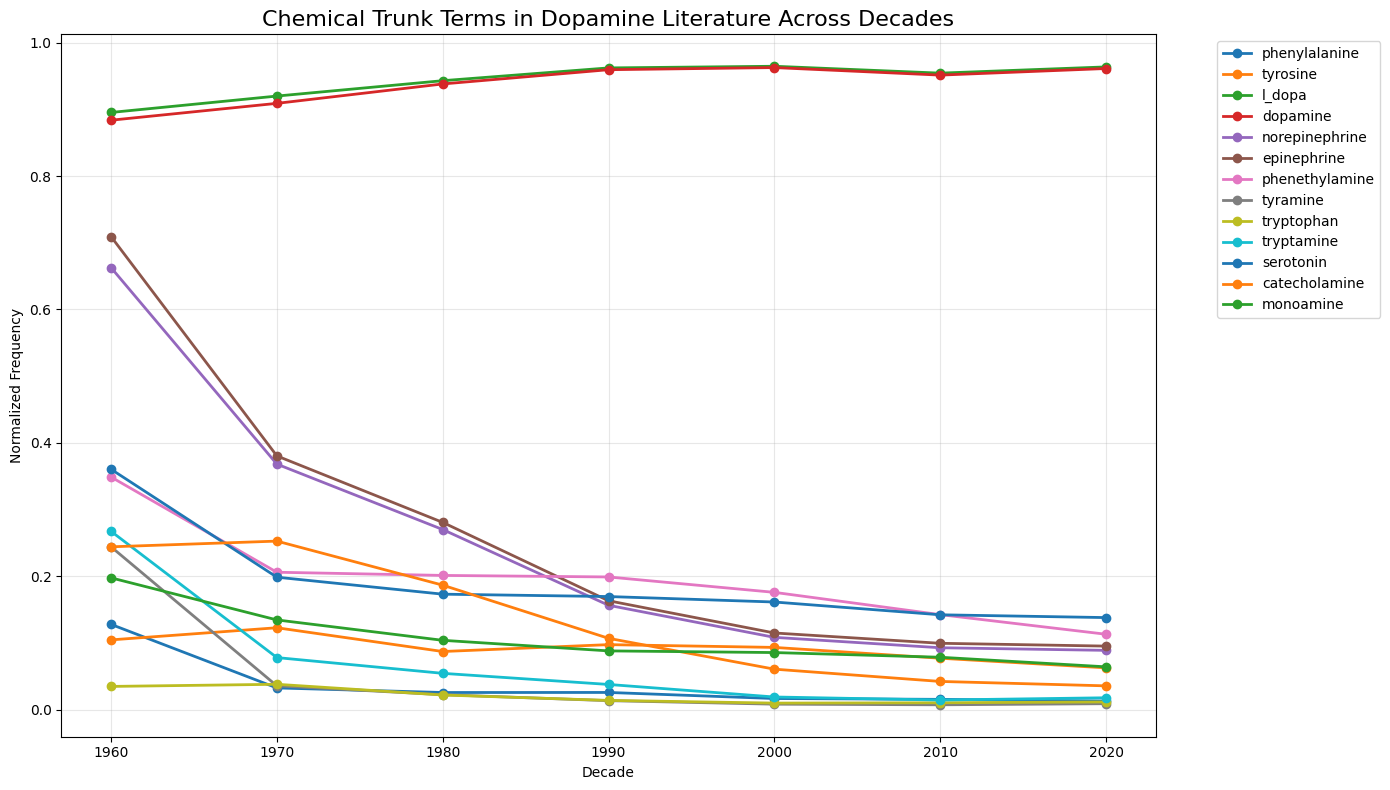

In [22]:
# --------------------------------------------------
# PLOT CHEMICAL TRUNK TRENDS
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for chem in trunk_trend_df["chemical"].unique():

    sub = trunk_trend_df[trunk_trend_df["chemical"] == chem]

    plt.plot(
        sub["decade"],
        sub["rate"],
        marker="o",
        linewidth=2,
        label=chem
    )

plt.title("Chemical Trunk Terms in Dopamine Literature Across Decades", fontsize=16)
plt.xlabel("Decade")
plt.ylabel("Normalized Frequency")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# --------------------------------------------------
# SAVE CHEMICAL TRUNK RESULTS
# --------------------------------------------------

trunk_timeline.to_csv(BASE / "dopamine_chemical_trunk_timeline.csv", index=False)
trunk_trend_df.to_csv(BASE / "dopamine_chemical_trunk_trends.csv", index=False)

print("Saved:")
print(BASE / "dopamine_chemical_trunk_timeline.csv")
print(BASE / "dopamine_chemical_trunk_trends.csv")

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_chemical_trunk_timeline.csv
C:\neurofeedback_models\dopamine_20251202\dopamine_chemical_trunk_trends.csv


In [24]:
# --------------------------------------------------
# BUILD CLEAN TEXT CORPUS
# --------------------------------------------------

import re
from collections import Counter

# combine title + abstract
df["text_blob"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
)

# lowercase
text = " ".join(df["text_blob"].astype(str).tolist()).lower()

# remove punctuation/numbers
text = re.sub(r"[^a-z\s\-]", " ", text)

print("Corpus length:", len(text))

Corpus length: 242875346


In [25]:
# --------------------------------------------------
# STOPWORDS
# --------------------------------------------------

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS)

domain_stopwords = {
    "dopamine",
    "brain",
    "study",
    "studies",
    "effect",
    "effects",
    "results",
    "using",
    "used",
    "patients",
    "rat",
    "rats",
    "mouse",
    "mice",
    "human",
    "humans",
    "treatment",
    "activity",
    "activities",
    "increase",
    "decrease",
    "associated",
    "analysis",
    "role",
    "mechanism",
    "mechanisms",
    "neural",
    "neurons",
    "system",
    "response",
    "responses",
    "cells",
    "cell",
    "receptor",
    "receptors",
    "disease",
    "disorders",
    "clinical",
    "levels",
    "function",
    "functions",
    "model",
    "models",
    "induced",
    "different",
    "group",
    "groups",
    "significant"
}

all_stopwords = custom_stopwords.union(domain_stopwords)

In [26]:
# --------------------------------------------------
# TOKENIZE
# --------------------------------------------------

tokens = text.split()

tokens = [
    t for t in tokens
    if len(t) > 3
    and t not in all_stopwords
]

print("Filtered tokens:", len(tokens))

Filtered tokens: 16292247


In [27]:
# --------------------------------------------------
# TOP TERMS
# --------------------------------------------------

term_counts = Counter(tokens)

top25 = pd.DataFrame(
    term_counts.most_common(25),
    columns=["term", "count"]
)

top25["percent"] = (
    top25["count"] /
    top25["count"].sum()
)

print(top25)

              term  count   percent
0     dopaminergic  81705  0.078551
1        increased  66744  0.064167
2          release  56581  0.054397
3        parkinson  50456  0.048508
4    significantly  48117  0.046260
5       expression  46982  0.045168
6         striatum  44502  0.042784
7         striatal  43980  0.042282
8          changes  42680  0.041032
9          control  40392  0.038833
10            acid  39495  0.037970
11  administration  38823  0.037324
12         binding  38211  0.036736
13         nucleus  35951  0.034563
14         suggest  35698  0.034320
15        compared  35223  0.033863
16          showed  34711  0.033371
17         reduced  34512  0.033180
18        observed  33692  0.032391
19       serotonin  32899  0.031629
20       decreased  32554  0.031297
21           motor  31726  0.030501
22            drug  31668  0.030446
23         present  31664  0.030442
24            data  31187  0.029983


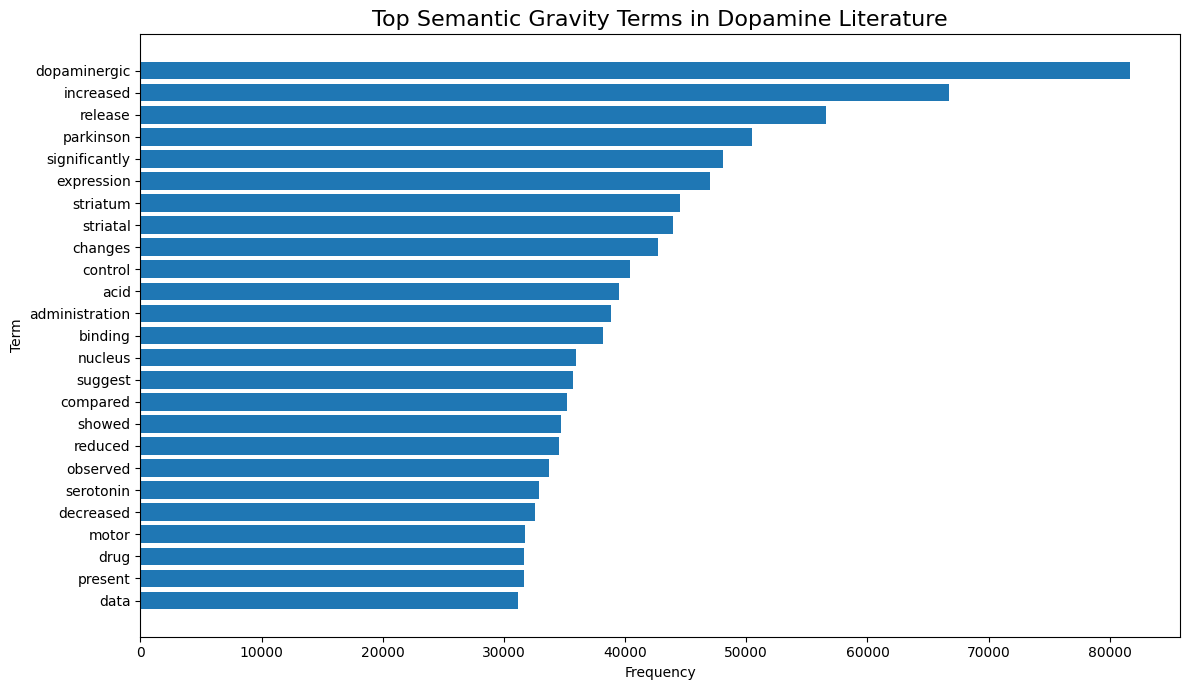

In [28]:
# --------------------------------------------------
# PLOT
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

plt.barh(
    top25["term"][::-1],
    top25["count"][::-1]
)

plt.title(
    "Top Semantic Gravity Terms in Dopamine Literature",
    fontsize=16
)

plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

In [29]:
# --------------------------------------------------
# SAVE
# --------------------------------------------------

top25.to_csv(
    BASE / "dopamine_top25_semantic_gravity.csv",
    index=False
)

print("Saved:")
print(BASE / "dopamine_top25_semantic_gravity.csv")

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_top25_semantic_gravity.csv


In [30]:
# --------------------------------------------------
# MONOAMINE vs CATECHOLAMINE TRENDS
# --------------------------------------------------

comparison_terms = {
    "catecholamine": [
        "catecholamine",
        "catecholamines"
    ],

    "monoamine": [
        "monoamine",
        "monoamines",
        "biogenic amine",
        "biogenic amines"
    ]
}

compare_results = []

for label, terms in comparison_terms.items():

    mask = df["text_blob"].apply(
        lambda x: any(term in x for term in terms)
    )

    temp = (
        df[mask]
        .groupby("decade")
        .size()
    )

    for decade, count in temp.items():

        compare_results.append({
            "term_family": label,
            "decade": decade,
            "count": count
        })

compare_df = pd.DataFrame(compare_results)

# --------------------------------------------------
# NORMALIZE
# --------------------------------------------------

total_by_decade = (
    df.groupby("decade")
      .size()
      .rename("total_papers")
)

compare_df = compare_df.merge(
    total_by_decade,
    on="decade"
)

compare_df["rate"] = (
    compare_df["count"] /
    compare_df["total_papers"]
)

print(compare_df.head())

     term_family  decade  count  total_papers      rate
0  catecholamine    1960     21            86  0.244186
1  catecholamine    1970   1257          5120  0.245508
2  catecholamine    1980   3802         20845  0.182394
3  catecholamine    1990   3043         29017  0.104870
4  catecholamine    2000   1993         33557  0.059391


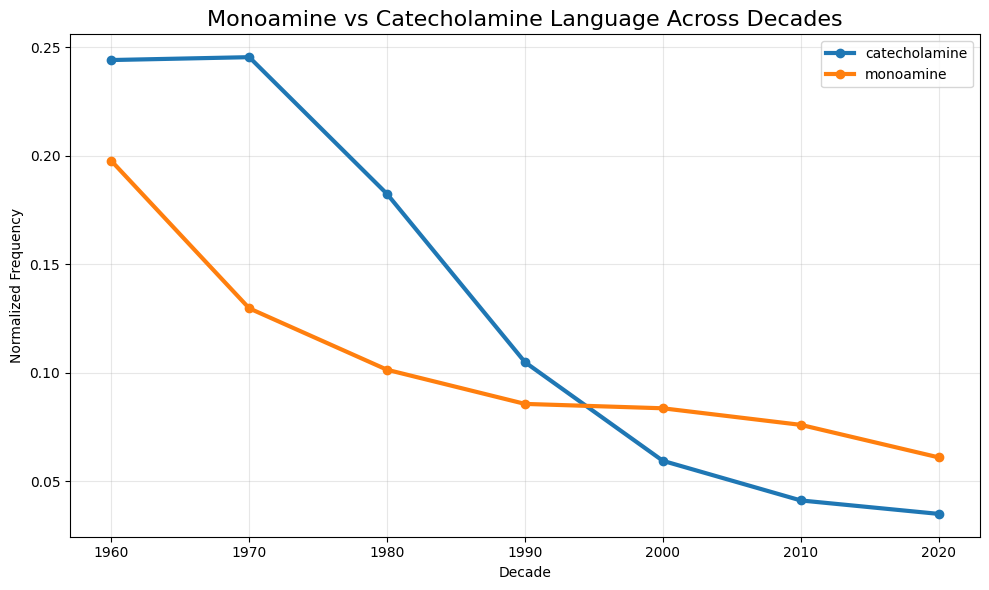

In [31]:
# --------------------------------------------------
# PLOT
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for label in compare_df["term_family"].unique():

    sub = compare_df[
        compare_df["term_family"] == label
    ]

    plt.plot(
        sub["decade"],
        sub["rate"],
        marker="o",
        linewidth=3,
        label=label
    )

plt.title(
    "Monoamine vs Catecholamine Language Across Decades",
    fontsize=16
)

plt.xlabel("Decade")
plt.ylabel("Normalized Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# --------------------------------------------------
# RECEPTOR LANGUAGE ACROSS DECADES
# --------------------------------------------------

receptor_terms = [
    "receptor",
    "receptors",
    "dopamine receptor",
    "dopamine receptors",
    "d1 receptor",
    "d2 receptor",
    "d3 receptor",
    "d4 receptor",
    "d5 receptor",
    "dopaminergic receptor",
    "receptor binding",
    "receptor subtype"
]

# --------------------------------------------------
# DETECT RECEPTOR LANGUAGE
# --------------------------------------------------

mask = df["text_blob"].apply(
    lambda x: any(term in x for term in receptor_terms)
)

receptor_df = df[mask].copy()

print("Receptor papers:", len(receptor_df))

# --------------------------------------------------
# COUNT BY DECADE
# --------------------------------------------------

receptor_trend = (
    receptor_df
    .groupby("decade")
    .size()
    .reset_index(name="count")
)

# --------------------------------------------------
# NORMALIZE
# --------------------------------------------------

total_by_decade = (
    df.groupby("decade")
      .size()
      .rename("total_papers")
      .reset_index()
)

receptor_trend = receptor_trend.merge(
    total_by_decade,
    on="decade"
)

receptor_trend["normalized_rate"] = (
    receptor_trend["count"] /
    receptor_trend["total_papers"]
)

print(receptor_trend)

Receptor papers: 58739
   decade  count  total_papers  normalized_rate
0    1960      9            86         0.104651
1    1970   1234          5120         0.241016
2    1980   7165         20845         0.343728
3    1990  12574         29017         0.433332
4    2000  14261         33557         0.424978
5    2010  15218         41695         0.364984
6    2020   8278         27253         0.303746


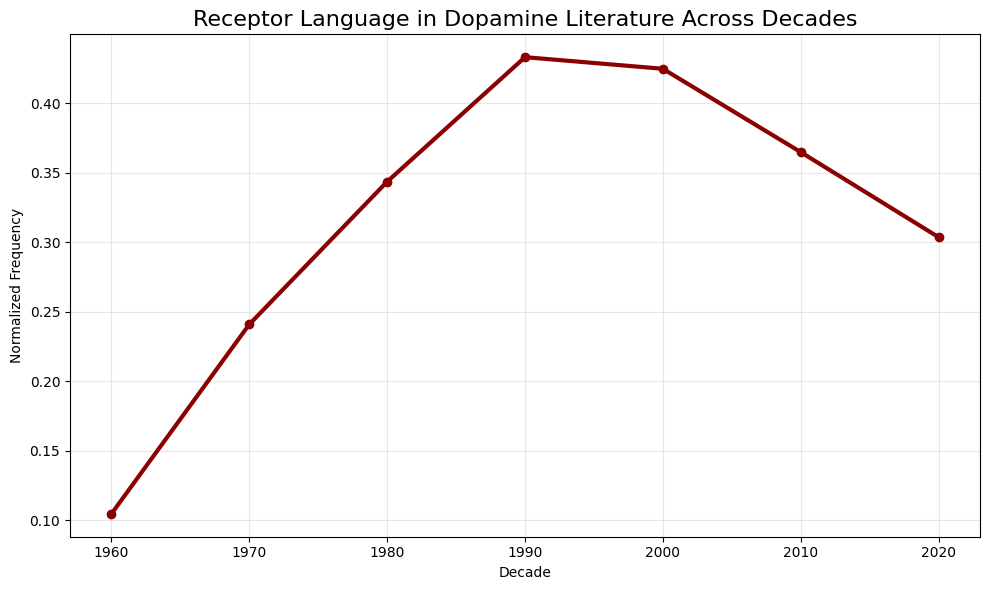

In [33]:
# --------------------------------------------------
# PLOT RECEPTOR LANGUAGE GROWTH
# --------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    receptor_trend["decade"],
    receptor_trend["normalized_rate"],
    marker="o",
    linewidth=3,
    color="darkred"
)

plt.title(
    "Receptor Language in Dopamine Literature Across Decades",
    fontsize=16
)

plt.xlabel("Decade")
plt.ylabel("Normalized Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# --------------------------------------------------
# EARLIEST RECEPTOR PAPERS
# --------------------------------------------------

early_receptors = (
    receptor_df[
        ["year_num", "title"]
    ]
    .sort_values("year_num")
    .head(30)
)

print("\n=== EARLY RECEPTOR PAPERS ===")
print(early_receptors.to_string(index=False))


=== EARLY RECEPTOR PAPERS ===
 year_num                                                                                                                                        title
   1962.0                                          Effect of sympathomimetic amines on the blocking action of guanethidine, bretylium and xylocholine.
   1964.0                            THE EFFECTS OF ADRENALINE AND OTHER DRUGS AFFECTING CARBOHYDRATE METABOLISM ON CONTRACTIONS OF THE RAT DIAPHRAGM.
   1965.0                                         Psychotropic drugs (2). Interaction between monoamine oxidase (MAO) inhibitors and other substances.
   1967.0 Temperature changes produced by the injection of catecholamines and 5-hydroxytryptamine into the cerebral ventricles of the conscious mouse.
   1967.0                                                                   The responses of thalamic neurons to iontophoretically applied monoamines.
   1968.0                                               Evidenc

In [35]:
# --------------------------------------------------
# SAVE
# --------------------------------------------------

receptor_trend.to_csv(
    BASE / "dopamine_receptor_language_trends.csv",
    index=False
)

early_receptors.to_csv(
    BASE / "dopamine_early_receptor_papers.csv",
    index=False
)

print("Saved:")
print(BASE / "dopamine_receptor_language_trends.csv")
print(BASE / "dopamine_early_receptor_papers.csv")

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_receptor_language_trends.csv
C:\neurofeedback_models\dopamine_20251202\dopamine_early_receptor_papers.csv


            term   count  percent_of_top50
0       dopamine  317773          0.120115
1        effects  110451          0.041749
2       receptor  105533          0.039890
3           rats   97084          0.036697
4        neurons   91808          0.034703
5       patients   86893          0.032845
6       activity   83431          0.031536
7   dopaminergic   81705          0.030884
8          brain   80394          0.030388
9      receptors   77144          0.029160
10        effect   76618          0.028961
11       disease   69864          0.026408
12         cells   65131          0.024619
13       release   56581          0.021387
14          mice   56467          0.021344
15     parkinson   50456          0.019072
16    expression   46982          0.017759
17      striatum   44502          0.016821
18          role   44198          0.016706
19      striatal   43980          0.016624
20      response   43748          0.016536
21          acid   39495          0.014929
22    assoc

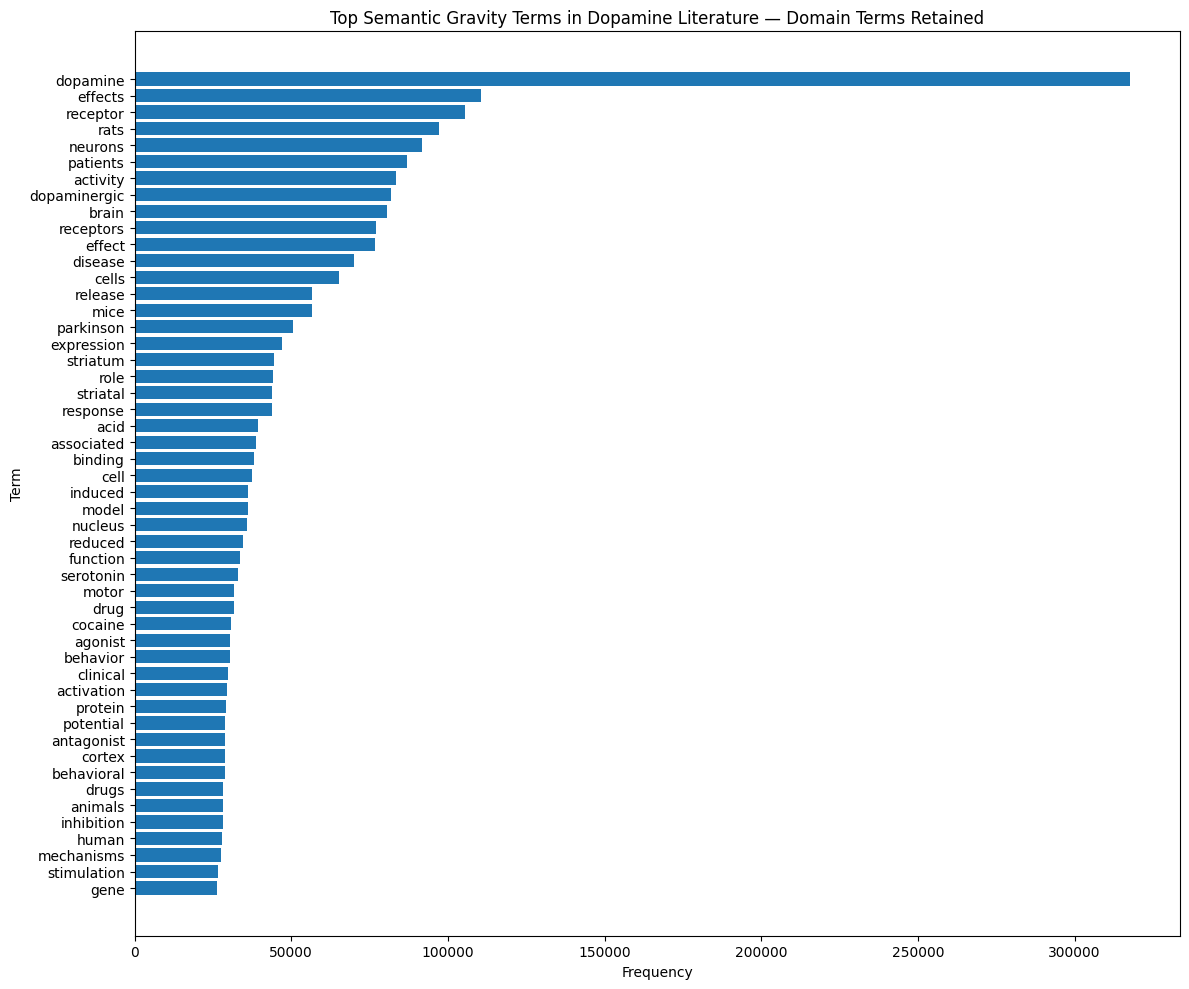

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_top50_semantic_gravity_domain_retained.csv


In [36]:
# --------------------------------------------------
# TOP SEMANTIC GRAVITY TERMS — BASE CORPUS LANGUAGE
# --------------------------------------------------

import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df["text_blob"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
)

text = " ".join(df["text_blob"].astype(str).tolist()).lower()
text = re.sub(r"[^a-z\s\-]", " ", text)

# Keep domain terms like brain, receptor, disease, motor, striatum.
# Remove only generic English + weak reporting/science filler.
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "study", "studies", "studied",
    "result", "results",
    "method", "methods",
    "using", "used", "use",
    "show", "shows", "showed", "shown",
    "suggest", "suggests", "suggested",
    "indicate", "indicates", "indicated",
    "present", "observed",
    "including", "compared", "comparison",
    "significant", "significantly",
    "increase", "increased", "decrease", "decreased",
    "changes", "change",
    "data", "analysis", "analyses",
    "group", "groups",
    "control", "controls",
    "treated", "treatment",
    "administration",
    "following",
    "different", "various",
    "levels", "level",
    "high", "low",
    "new"
})

tokens = text.split()

tokens = [
    t for t in tokens
    if len(t) > 3
    and t not in custom_stopwords
]

term_counts = Counter(tokens)

top50 = pd.DataFrame(
    term_counts.most_common(50),
    columns=["term", "count"]
)

top50["percent_of_top50"] = top50["count"] / top50["count"].sum()

print(top50.head(50))

plt.figure(figsize=(12, 10))
plt.barh(top50["term"][::-1], top50["count"][::-1])
plt.title("Top Semantic Gravity Terms in Dopamine Literature — Domain Terms Retained")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

top50.to_csv(BASE / "dopamine_top50_semantic_gravity_domain_retained.csv", index=False)

print("Saved:")
print(BASE / "dopamine_top50_semantic_gravity_domain_retained.csv")

C:\Users\rexca\AppData\Local\Temp\ipykernel_9880\4021193631.py:31: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mono_base["monoamine"] = mono_base["text_lower"].str.contains(


Monoamine papers: 12151


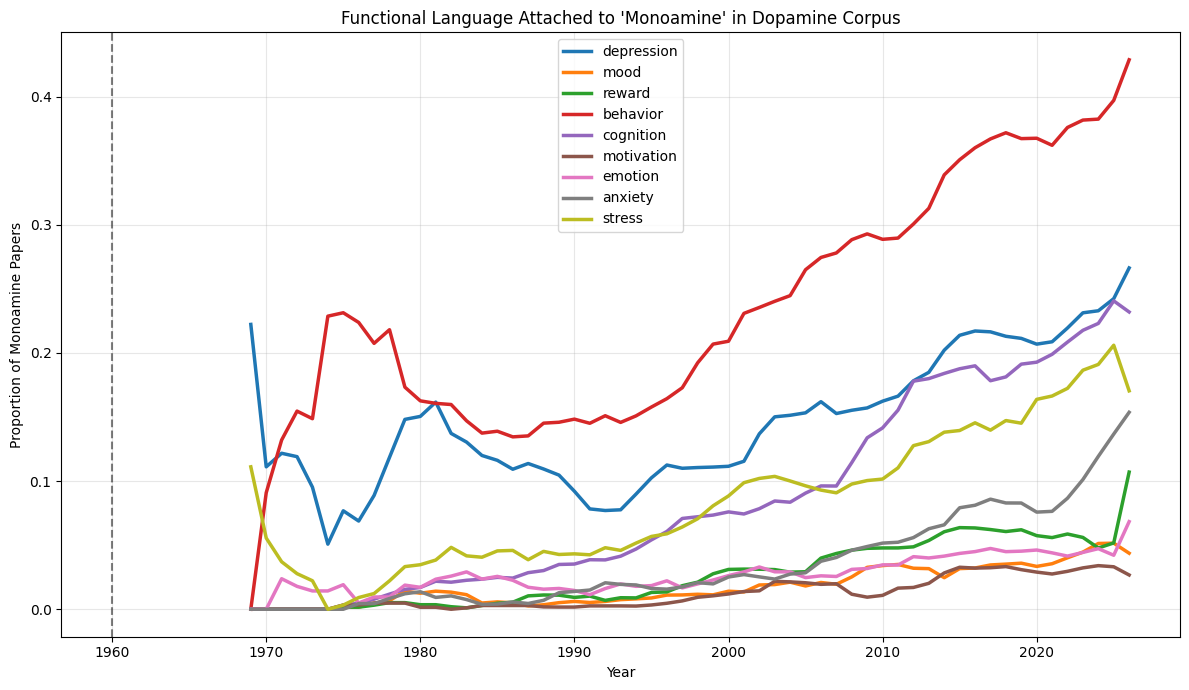

Saved:
C:\neurofeedback_models\dopamine_20251202\dopamine_monoamine_functional_language_by_year.csv


In [37]:
# --------------------------------------------------
# FUNCTIONAL LANGUAGE ATTACHED TO "MONOAMINE"
# Dopamine corpus version
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# use current dopamine dataframe
mono_base = df.copy()

# build text field
mono_base["text"] = (
    mono_base["title"].fillna("") + " " +
    mono_base["abstract"].fillna("")
)

mono_base["text_lower"] = mono_base["text"].str.lower()

# make sure year is numeric
mono_base["year_num"] = pd.to_numeric(
    mono_base["year"].astype(str).str[:4],
    errors="coerce"
)

# --------------------------------------------------
# MONOAMINE FILTER
# --------------------------------------------------

mono_base["monoamine"] = mono_base["text_lower"].str.contains(
    r"\bmonoamine(s)?\b|\bbiogenic amine(s)?\b",
    regex=True,
    na=False
)

mono_df = mono_base[mono_base["monoamine"]].copy()

print("Monoamine papers:", len(mono_df))

# --------------------------------------------------
# FUNCTIONAL TERMS
# --------------------------------------------------

terms = {
    "depression": r"depress",
    "mood": r"\bmood\b",
    "reward": r"reward|reinforcement",
    "behavior": r"behavior|behaviour",
    "cognition": r"cognit|attention|memory|learning",
    "motivation": r"motiv|incentive",
    "emotion": r"emotion|affective",
    "anxiety": r"anxiety|anxiolytic",
    "stress": r"stress"
}

# flag terms
for name, pattern in terms.items():
    mono_df[name] = mono_df["text_lower"].str.contains(
        pattern,
        regex=True,
        na=False
    )

# --------------------------------------------------
# YEARLY AGGREGATION
# --------------------------------------------------

yearly = (
    mono_df
    .dropna(subset=["year_num"])
    .groupby("year_num")
    .agg({key: "mean" for key in terms.keys()})
    .reset_index()
)

counts = (
    mono_df
    .dropna(subset=["year_num"])
    .groupby("year_num")
    .size()
    .reset_index(name="n")
)

yearly = yearly.merge(counts, on="year_num")

# reduce unstable tiny-year spikes
yearly = yearly[yearly["n"] >= 5].copy()

# rolling smooth
for key in terms.keys():
    yearly[f"{key}_smooth"] = (
        yearly[key]
        .rolling(window=5, min_periods=1)
        .mean()
    )

# --------------------------------------------------
# PLOT
# --------------------------------------------------

plt.figure(figsize=(12, 7))

for key in terms.keys():
    plt.plot(
        yearly["year_num"],
        yearly[f"{key}_smooth"],
        linewidth=2.5,
        label=key
    )

plt.axvline(1960, linestyle="--", color="black", alpha=0.5)

plt.title("Functional Language Attached to 'Monoamine' in Dopamine Corpus")
plt.xlabel("Year")
plt.ylabel("Proportion of Monoamine Papers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# SAVE
# --------------------------------------------------

yearly.to_csv(
    BASE / "dopamine_monoamine_functional_language_by_year.csv",
    index=False
)

print("Saved:")
print(BASE / "dopamine_monoamine_functional_language_by_year.csv")

Loaded: (157573, 10)
motor 44694
reward 10664
motivation 4415
cognition 19055
learning 7673
emotion 2127
addiction 5965
adhd 2383
schizophrenia 13274
depression 12056
anxiety 3996
stress 11120
inhibition 17237


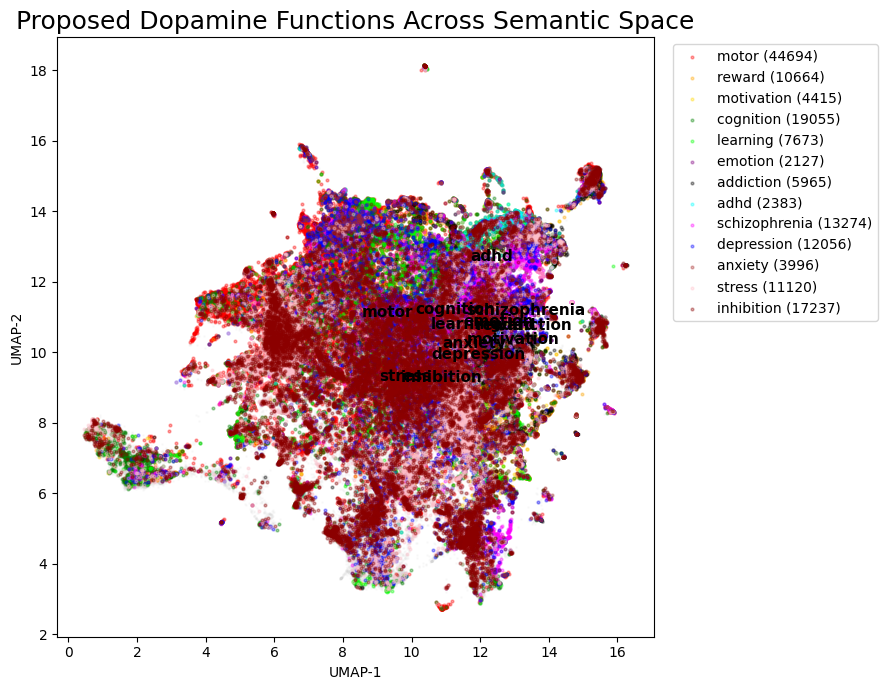


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_function_overlay_map_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_function_centroids_v001.csv


In [38]:
# ==================================================
# TS FUNCTION OVERLAY MAP
# Proposed Dopamine Functions in UMAP Space
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD TS MASTER
# --------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

print("Loaded:", df.shape)

# --------------------------------------------------
# BUILD TEXT
# --------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# --------------------------------------------------
# FUNCTION DOMAINS
# --------------------------------------------------

functions = {

    "motor":
        r"\bmotor\b|movement|locomot|parkinson",

    "reward":
        r"\breward\b|reinforcement|hedonic",

    "motivation":
        r"\bmotiv",

    "cognition":
        r"cognit|attention|memory|executive",

    "learning":
        r"\blearning\b|conditioning",

    "emotion":
        r"\bemotion\b|affective",

    "addiction":
        r"addiction|substance use|drug abuse",

    "adhd":
        r"\badhd\b|attention deficit",

    "schizophrenia":
        r"schizophrenia|psychosis|psychotic",

    "depression":
        r"depress|mood disorder",

    "anxiety":
        r"\banxiety\b|anxious",

    "stress":
        r"\bstress\b",

    "inhibition":
        r"\binhibition\b|inhibitory control"
}

# --------------------------------------------------
# FLAG DOMAINS
# --------------------------------------------------

for name, pattern in functions.items():

    df[name] = df["text_lower"].str.contains(
        pattern,
        regex=True,
        na=False
    )

# --------------------------------------------------
# BASE PLOT
# --------------------------------------------------

plt.figure(figsize=(9,7))

# background manifold
plt.scatter(
    df["UMAP-1"],
    df["UMAP-2"],
    s=1,
    alpha=0.08,
    color="lightgray"
)

# --------------------------------------------------
# COLORS
# --------------------------------------------------

colors = {
    "motor": "red",
    "reward": "orange",
    "motivation": "gold",
    "cognition": "green",
    "learning": "lime",
    "emotion": "purple",
    "addiction": "black",
    "adhd": "cyan",
    "schizophrenia": "magenta",
    "depression": "blue",
    "anxiety": "brown",
    "stress": "pink",
    "inhibition": "darkred"
}

# --------------------------------------------------
# OVERLAY EACH FUNCTION
# --------------------------------------------------

centroids = []

for func in functions.keys():

    subset = df[df[func]]

    print(func, len(subset))

    plt.scatter(
        subset["UMAP-1"],
        subset["UMAP-2"],
        s=4,
        alpha=0.35,
        label=f"{func} ({len(subset)})",
        color=colors[func]
    )

    # centroid
    cx = subset["UMAP-1"].mean()
    cy = subset["UMAP-2"].mean()

    centroids.append({
        "function": func,
        "x": cx,
        "y": cy,
        "n": len(subset)
    })

    plt.text(
        cx,
        cy,
        func,
        fontsize=11,
        weight="bold"
    )

# --------------------------------------------------
# FINALIZE
# --------------------------------------------------

plt.title(
    "Proposed Dopamine Functions Across Semantic Space",
    fontsize=18
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# --------------------------------------------------
# SAVE FIGURE
# --------------------------------------------------

plt.savefig(
    f"{BASE}\\dopamine_function_overlay_map_v001.png",
    dpi=300
)

plt.show()

# --------------------------------------------------
# SAVE CENTROIDS
# --------------------------------------------------

centroid_df = pd.DataFrame(centroids)

centroid_df.to_csv(
    f"{BASE}\\dopamine_function_centroids_v001.csv",
    index=False
)

print("\nSaved:")
print(f"{BASE}\\dopamine_function_overlay_map_v001.png")
print(f"{BASE}\\dopamine_function_centroids_v001.csv")

In [39]:
# ==================================================
# EARLY DOPAMINE THEORY PAPERS
# Functional Origin Mapping
# ==================================================

import pandas as pd

# --------------------------------------------------
# LOAD TS MASTER
# --------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# --------------------------------------------------
# TEXT FIELD
# --------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# --------------------------------------------------
# YEAR
# --------------------------------------------------

df["year_num"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

# --------------------------------------------------
# FUNCTION DOMAINS
# --------------------------------------------------

functions = {

    "motor":
        r"\bmotor\b|movement|locomot|parkinson",

    "reward":
        r"\breward\b|reinforcement|hedonic",

    "motivation":
        r"\bmotiv",

    "cognition":
        r"cognit|attention|memory|executive",

    "learning":
        r"\blearning\b|conditioning",

    "emotion":
        r"\bemotion\b|affective",

    "inhibition":
        r"\binhibition\b|inhibitory control"
}

# --------------------------------------------------
# FIND EARLIEST PAPERS
# --------------------------------------------------

early_tables = []

for func, pattern in functions.items():

    subset = df[
        df["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ].copy()

    subset = subset.sort_values("year_num")

    early = subset[
        ["year_num", "pmid", "title"]
    ].head(20)

    early["function"] = func

    early_tables.append(early)

    print("\n" + "="*70)
    print(func.upper())
    print("="*70)

    print(
        early[
            ["year_num", "title"]
        ].to_string(index=False)
    )

# --------------------------------------------------
# COMBINE
# --------------------------------------------------

early_df = pd.concat(
    early_tables,
    ignore_index=True
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

OUT = (
    f"{BASE}\\dopamine_early_theory_papers_v001.csv"
)

early_df.to_csv(
    OUT,
    index=False
)

print("\nSaved:")
print(OUT)


MOTOR
 year_num                                                                                                                                              title
   1961.0                                                                                                Excretion of dopamine in diseases of basal ganglia.
   1964.0                                                                                 ADMINISTRATION OF DIHYDROXYPHENYLALANINE TO PARKINSONIAN PATIENTS.
   1965.0                                               Psychotropic drugs (2). Interaction between monoamine oxidase (MAO) inhibitors and other substances.
   1966.0                                                                                     Neurochemical bases of tremor and other disorders of movement.
   1968.0                                         Histochemical fluorescence after application of neurochemicals to caudate nucleus and septal area in vivo.
   1969.0                                          

Early motor papers: 864

GLOBAL CENTROID
9.338407141005693 9.355364953551687

EARLY MOTOR CENTROID
9.976166573263889 9.803493894675926

Distance from global center: 0.7794591979747422


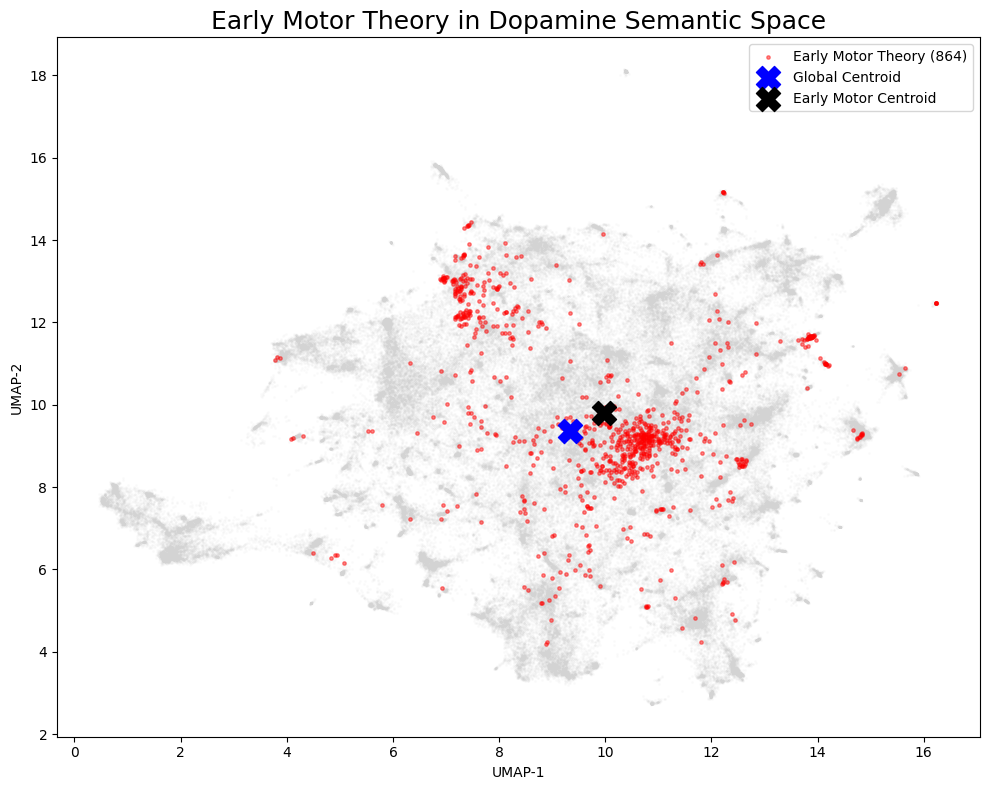


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_early_motor_geometry_v001.png


In [40]:
# ==================================================
# EARLY MOTOR THEORY GEOMETRY
# Does early motor theory occupy the manifold center?
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD
# --------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# --------------------------------------------------
# TEXT
# --------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# --------------------------------------------------
# YEAR
# --------------------------------------------------

df["year_num"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

# --------------------------------------------------
# EARLY MOTOR THEORY FILTER
# --------------------------------------------------

motor_pattern = (
    r"\bmotor\b|movement|locomot|parkinson"
)

early_motor = df[
    (
        df["year_num"] <= 1980
    )
    &
    (
        df["text_lower"].str.contains(
            motor_pattern,
            regex=True,
            na=False
        )
    )
].copy()

print("Early motor papers:", len(early_motor))

# --------------------------------------------------
# GLOBAL CENTROID
# --------------------------------------------------

global_x = df["UMAP-1"].mean()
global_y = df["UMAP-2"].mean()

# --------------------------------------------------
# MOTOR CENTROID
# --------------------------------------------------

motor_x = early_motor["UMAP-1"].mean()
motor_y = early_motor["UMAP-2"].mean()

print("\nGLOBAL CENTROID")
print(global_x, global_y)

print("\nEARLY MOTOR CENTROID")
print(motor_x, motor_y)

# --------------------------------------------------
# DISTANCE
# --------------------------------------------------

dist = np.sqrt(
    (global_x - motor_x)**2 +
    (global_y - motor_y)**2
)

print("\nDistance from global center:", dist)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

plt.figure(figsize=(10,8))

# full manifold
plt.scatter(
    df["UMAP-1"],
    df["UMAP-2"],
    s=1,
    alpha=0.06,
    color="lightgray"
)

# early motor papers
plt.scatter(
    early_motor["UMAP-1"],
    early_motor["UMAP-2"],
    s=6,
    alpha=0.45,
    color="red",
    label=f"Early Motor Theory ({len(early_motor)})"
)

# global centroid
plt.scatter(
    global_x,
    global_y,
    s=300,
    color="blue",
    marker="X",
    label="Global Centroid"
)

# motor centroid
plt.scatter(
    motor_x,
    motor_y,
    s=300,
    color="black",
    marker="X",
    label="Early Motor Centroid"
)

plt.title(
    "Early Motor Theory in Dopamine Semantic Space",
    fontsize=18
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend()

plt.tight_layout()

# --------------------------------------------------
# SAVE
# --------------------------------------------------

plt.savefig(
    f"{BASE}\\dopamine_early_motor_geometry_v001.png",
    dpi=300
)

plt.show()

print("\nSaved:")
print(
    f"{BASE}\\dopamine_early_motor_geometry_v001.png"
)


GLOBAL CENTROID
9.338407141005693 9.355364953551687


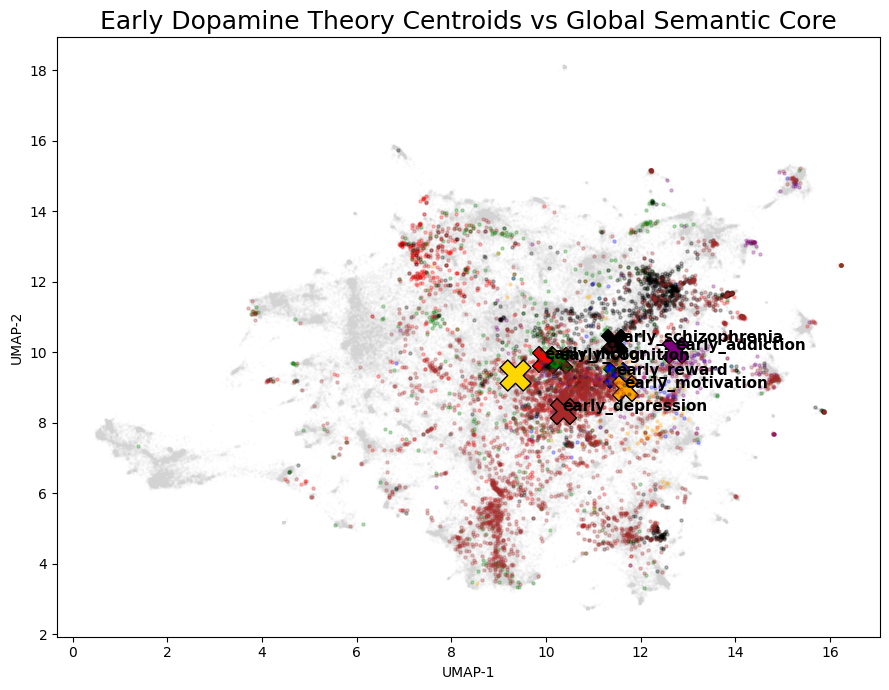


=== DISTANCES TO GLOBAL CORE ===
              function     n  centroid_x  centroid_y  distance_to_global_core
0          early_motor   864    9.976167    9.803494                 0.779459
2      early_cognition   639   10.287177    9.786665                 1.042201
6     early_depression  2698   10.355312    8.343689                 1.434428
1         early_reward   202   11.481409    9.351067                 2.143006
5  early_schizophrenia  1161   11.429474   10.276857                 2.285105
3     early_motivation   122   11.668296    8.985650                 2.359041
4      early_addiction   187   12.732255   10.070112                 3.468295

Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_early_theory_centroids_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_early_theory_centroid_distances_v001.csv


In [41]:
# ==================================================
# TS CENTROID DISTANCE TO GLOBAL CORE
# Motor vs Reward vs Cognition vs Others
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD
# --------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# --------------------------------------------------
# TEXT
# --------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# --------------------------------------------------
# YEAR
# --------------------------------------------------

df["year_num"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

# --------------------------------------------------
# FUNCTION DOMAINS
# --------------------------------------------------

functions = {

    "early_motor":
        (
            (df["year_num"] <= 1980),
            r"\bmotor\b|movement|locomot|parkinson"
        ),

    "early_reward":
        (
            (df["year_num"] <= 1985),
            r"\breward\b|reinforcement|hedonic"
        ),

    "early_cognition":
        (
            (df["year_num"] <= 1990),
            r"cognit|attention|memory|executive"
        ),

    "early_motivation":
        (
            (df["year_num"] <= 1990),
            r"\bmotiv"
        ),

    "early_addiction":
        (
            (df["year_num"] <= 1995),
            r"addiction|substance use|drug abuse"
        ),

    "early_schizophrenia":
        (
            (df["year_num"] <= 1990),
            r"schizophrenia|psychosis|psychotic"
        ),

    "early_depression":
        (
            (df["year_num"] <= 1995),
            r"depress|mood disorder"
        )
}

# --------------------------------------------------
# GLOBAL CENTROID
# --------------------------------------------------

global_x = df["UMAP-1"].mean()
global_y = df["UMAP-2"].mean()

print("\nGLOBAL CENTROID")
print(global_x, global_y)

# --------------------------------------------------
# COMPUTE CENTROIDS
# --------------------------------------------------

results = []

plt.figure(figsize=(9,7))

# background manifold
plt.scatter(
    df["UMAP-1"],
    df["UMAP-2"],
    s=1,
    alpha=0.04,
    color="lightgray"
)

colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "black",
    "brown"
]

for i, (name, (year_filter, pattern)) in enumerate(functions.items()):

    subset = df[
        year_filter &
        (
            df["text_lower"].str.contains(
                pattern,
                regex=True,
                na=False
            )
        )
    ].copy()

    cx = subset["UMAP-1"].mean()
    cy = subset["UMAP-2"].mean()

    dist = np.sqrt(
        (global_x - cx)**2 +
        (global_y - cy)**2
    )

    results.append({
        "function": name,
        "n": len(subset),
        "centroid_x": cx,
        "centroid_y": cy,
        "distance_to_global_core": dist
    })

    # plot subset
    plt.scatter(
        subset["UMAP-1"],
        subset["UMAP-2"],
        s=5,
        alpha=0.25,
        color=colors[i]
    )

    # centroid
    plt.scatter(
        cx,
        cy,
        s=350,
        color=colors[i],
        marker="X",
        edgecolor="black"
    )

    plt.text(
        cx,
        cy,
        name,
        fontsize=11,
        weight="bold"
    )

# --------------------------------------------------
# GLOBAL CORE
# --------------------------------------------------

plt.scatter(
    global_x,
    global_y,
    s=500,
    color="gold",
    marker="X",
    edgecolor="black",
    label="Global Core"
)

# --------------------------------------------------
# FINALIZE
# --------------------------------------------------

plt.title(
    "Early Dopamine Theory Centroids vs Global Semantic Core",
    fontsize=18
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.tight_layout()

# --------------------------------------------------
# SAVE FIGURE
# --------------------------------------------------

plt.savefig(
    f"{BASE}\\dopamine_early_theory_centroids_v001.png",
    dpi=300
)

plt.show()

# --------------------------------------------------
# SAVE RESULTS
# --------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "distance_to_global_core"
)

results_df.to_csv(
    f"{BASE}\\dopamine_early_theory_centroid_distances_v001.csv",
    index=False
)

print("\n=== DISTANCES TO GLOBAL CORE ===")
print(results_df)

print("\nSaved:")
print(f"{BASE}\\dopamine_early_theory_centroids_v001.png")
print(f"{BASE}\\dopamine_early_theory_centroid_distances_v001.csv")

Motor core centroid:
8.559689452491833 10.986372070949121


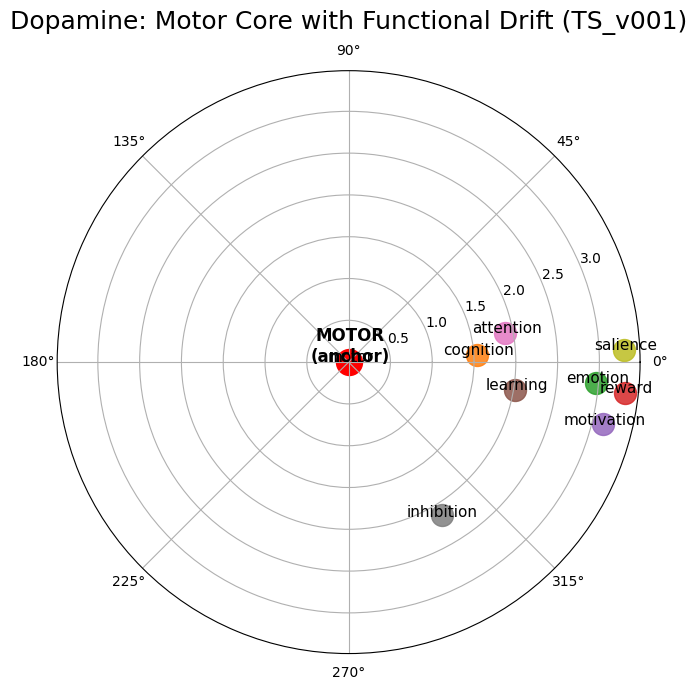


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_motor_core_drift_TS_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_motor_core_drift_TS_v001.csv


In [42]:
# ==================================================
# DOPAMINE MOTOR CORE WITH FUNCTIONAL DRIFT
# TS_v001 GEOMETRIC VERSION
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD
# --------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# --------------------------------------------------
# TEXT
# --------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# --------------------------------------------------
# FUNCTION TERMS
# --------------------------------------------------

functions = {

    "motor":
        r"\bmotor\b|movement|locomot|parkinson",

    "cognition":
        r"cognit|executive|memory|attention",

    "emotion":
        r"\bemotion\b|affective",

    "reward":
        r"\breward\b|reinforcement|hedonic",

    "motivation":
        r"\bmotiv",

    "learning":
        r"\blearning\b|conditioning",

    "attention":
        r"\battention\b",

    "inhibition":
        r"\binhibition\b|inhibitory control",

    "salience":
        r"\bsalience\b"
}

# --------------------------------------------------
# GLOBAL MOTOR CORE
# --------------------------------------------------

motor_df = df[
    df["text_lower"].str.contains(
        functions["motor"],
        regex=True,
        na=False
    )
]

motor_x = motor_df["UMAP-1"].mean()
motor_y = motor_df["UMAP-2"].mean()

print("Motor core centroid:")
print(motor_x, motor_y)

# --------------------------------------------------
# FUNCTION CENTROIDS
# --------------------------------------------------

results = []

for func, pattern in functions.items():

    subset = df[
        df["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ]

    if len(subset) < 50:
        continue

    cx = subset["UMAP-1"].mean()
    cy = subset["UMAP-2"].mean()

    dx = cx - motor_x
    dy = cy - motor_y

    # polar coordinates
    angle = np.arctan2(dy, dx)
    radius = np.sqrt(dx**2 + dy**2)

    results.append({
        "function": func,
        "n": len(subset),
        "centroid_x": cx,
        "centroid_y": cy,
        "angle": angle,
        "radius": radius
    })

# --------------------------------------------------
# DATAFRAME
# --------------------------------------------------

res_df = pd.DataFrame(results)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig = plt.figure(figsize=(8,7))

ax = plt.subplot(111, polar=True)

# plot each function
for _, row in res_df.iterrows():

    ax.scatter(
        row["angle"],
        row["radius"],
        s=250,
        alpha=0.85
    )

    ax.text(
        row["angle"],
        row["radius"] + 0.02,
        row["function"],
        fontsize=11,
        ha="center"
    )

# motor anchor
ax.scatter(
    0,
    0,
    s=350,
    color="red"
)

ax.text(
    0,
    0.02,
    "MOTOR\n(anchor)",
    ha="center",
    fontsize=12,
    weight="bold"
)

# --------------------------------------------------
# STYLE
# --------------------------------------------------

ax.set_title(
    "Dopamine: Motor Core with Functional Drift (TS_v001)",
    fontsize=18,
    pad=30
)

plt.tight_layout()

# --------------------------------------------------
# SAVE
# --------------------------------------------------

OUT_PNG = (
    f"{BASE}\\dopamine_motor_core_drift_TS_v001.png"
)

OUT_CSV = (
    f"{BASE}\\dopamine_motor_core_drift_TS_v001.csv"
)

plt.savefig(
    OUT_PNG,
    dpi=300
)

res_df.to_csv(
    OUT_CSV,
    index=False
)

plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_CSV)

In [43]:
# ==================================================
# TS_v001 DISTANCE ANALYSIS
# FULL EMBEDDING GEOMETRY
# ==================================================

import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean

# --------------------------------------------------
# LOAD TS MASTER
# --------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# --------------------------------------------------
# TEXT
# --------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# --------------------------------------------------
# FUNCTION DEFINITIONS
# --------------------------------------------------

functions = {

    "movement":
        r"\bmotor\b|movement|locomot|parkinson",

    "inhibition":
        r"\binhibition\b|inhibitory control|response suppression",

    "reward":
        r"\breward\b|reinforcement|hedonic",

    "salience":
        r"\bsalience\b",

    "cognition":
        r"cognit|attention|executive|memory",

    "motivation":
        r"\bmotiv",

    "emotion":
        r"\bemotion\b|affective",

    "learning":
        r"\blearning\b|conditioning"
}

# --------------------------------------------------
# COMPUTE CENTROIDS
# --------------------------------------------------

centroids = {}

for name, pattern in functions.items():

    subset = df[
        df["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ]

    cx = subset["UMAP-1"].mean()
    cy = subset["UMAP-2"].mean()

    centroids[name] = np.array([cx, cy])

    print(f"{name}: n={len(subset)} centroid=({cx:.3f}, {cy:.3f})")

# --------------------------------------------------
# PAIRWISE DISTANCES
# --------------------------------------------------

pairs = []

names = list(centroids.keys())

for i in range(len(names)):
    for j in range(i+1, len(names)):

        a = names[i]
        b = names[j]

        dist = euclidean(
            centroids[a],
            centroids[b]
        )

        pairs.append({
            "A": a,
            "B": b,
            "distance": dist
        })

dist_df = pd.DataFrame(pairs)

# --------------------------------------------------
# SORT
# --------------------------------------------------

dist_df = dist_df.sort_values("distance")

print("\n=== CLOSEST SEMANTIC PAIRS ===")
print(dist_df.head(20))

# --------------------------------------------------
# MOVEMENT COMPARISONS
# --------------------------------------------------

move_df = dist_df[
    (dist_df["A"] == "movement") |
    (dist_df["B"] == "movement")
].copy()

move_df["other"] = move_df.apply(
    lambda x:
        x["B"] if x["A"] == "movement"
        else x["A"],
    axis=1
)

move_df = move_df.sort_values("distance")

print("\n=== DISTANCES FROM MOVEMENT ===")
print(
    move_df[
        ["other", "distance"]
    ].to_string(index=False)
)

# --------------------------------------------------
# FIX RATIO TESTS + SAVE DISTANCE RESULTS
# --------------------------------------------------

move_inhib = move_df.loc[
    move_df["other"] == "inhibition",
    "distance"
].iloc[0]

move_reward = move_df.loc[
    move_df["other"] == "reward",
    "distance"
].iloc[0]

move_salience = move_df.loc[
    move_df["other"] == "salience",
    "distance"
].iloc[0]

move_cognition = move_df.loc[
    move_df["other"] == "cognition",
    "distance"
].iloc[0]

move_learning = move_df.loc[
    move_df["other"] == "learning",
    "distance"
].iloc[0]

ratio_summary = pd.DataFrame({
    "comparison": [
        "Reward / Inhibition",
        "Salience / Inhibition",
        "Reward / Cognition",
        "Reward / Learning",
        "Inhibition / Cognition"
    ],
    "ratio": [
        move_reward / move_inhib,
        move_salience / move_inhib,
        move_reward / move_cognition,
        move_reward / move_learning,
        move_inhib / move_cognition
    ]
})

print("\n=== TS RATIOS ===")
print(ratio_summary)

# save
dist_df.to_csv(
    f"{BASE}\\dopamine_TS_pairwise_semantic_distances_v001.csv",
    index=False
)

move_df.to_csv(
    f"{BASE}\\dopamine_TS_distances_from_movement_v001.csv",
    index=False
)

ratio_summary.to_csv(
    f"{BASE}\\dopamine_TS_movement_distance_ratios_v001.csv",
    index=False
)

print("\nSaved:")
print(f"{BASE}\\dopamine_TS_pairwise_semantic_distances_v001.csv")
print(f"{BASE}\\dopamine_TS_distances_from_movement_v001.csv")
print(f"{BASE}\\dopamine_TS_movement_distance_ratios_v001.csv")

movement: n=44694 centroid=(8.560, 10.986)
inhibition: n=17254 centroid=(9.675, 9.152)
reward: n=10664 centroid=(11.860, 10.621)
salience: n=640 centroid=(11.854, 11.127)
cognition: n=19055 centroid=(10.098, 11.075)
motivation: n=4415 centroid=(11.602, 10.243)
emotion: n=2127 centroid=(11.515, 10.742)
learning: n=7673 centroid=(10.556, 10.658)

=== CLOSEST SEMANTIC PAIRS ===
             A           B  distance
16      reward     emotion  0.365469
15      reward  motivation  0.457189
13      reward    salience  0.505588
25  motivation     emotion  0.506510
20    salience     emotion  0.512461
24   cognition    learning  0.618783
19    salience  motivation  0.918462
27     emotion    learning  0.963072
26  motivation    learning  1.125755
17      reward    learning  1.304685
21    salience    learning  1.380321
23   cognition     emotion  1.455212
3     movement   cognition  1.541309
22   cognition  motivation  1.718484
12  inhibition    learning  1.744129
18    salience   cognition  1.

dopamine: n=139165 centroid=(9.399, 9.354)
l_dopa: n=9653 centroid=(8.028, 11.039)
catecholamine: n=13074 centroid=(8.896, 7.654)
monoamine: n=11854 centroid=(9.658, 9.444)
phenylalanine: n=779 centroid=(8.289, 9.104)
tyrosine: n=12966 centroid=(8.295, 9.242)
tyramine: n=1198 centroid=(7.717, 8.057)
phenethylamine: n=308 centroid=(8.652, 9.066)
norepinephrine: n=21988 centroid=(9.626, 8.035)
epinephrine: n=6297 centroid=(8.498, 6.564)
tryptophan: n=1618 centroid=(9.057, 8.615)
tryptamine: n=382 centroid=(8.479, 8.434)
serotonin: n=22577 centroid=(10.152, 9.292)

=== CLOSEST TO GLOBAL CORE ===
              term  distance_to_global       n
0         dopamine            0.060457  139165
3        monoamine            0.331786   11854
7   phenethylamine            0.745238     308
10      tryptophan            0.791698    1618
12       serotonin            0.816437   22577
5         tyrosine            1.049705   12966
4    phenylalanine            1.079181     779
11      tryptamine      

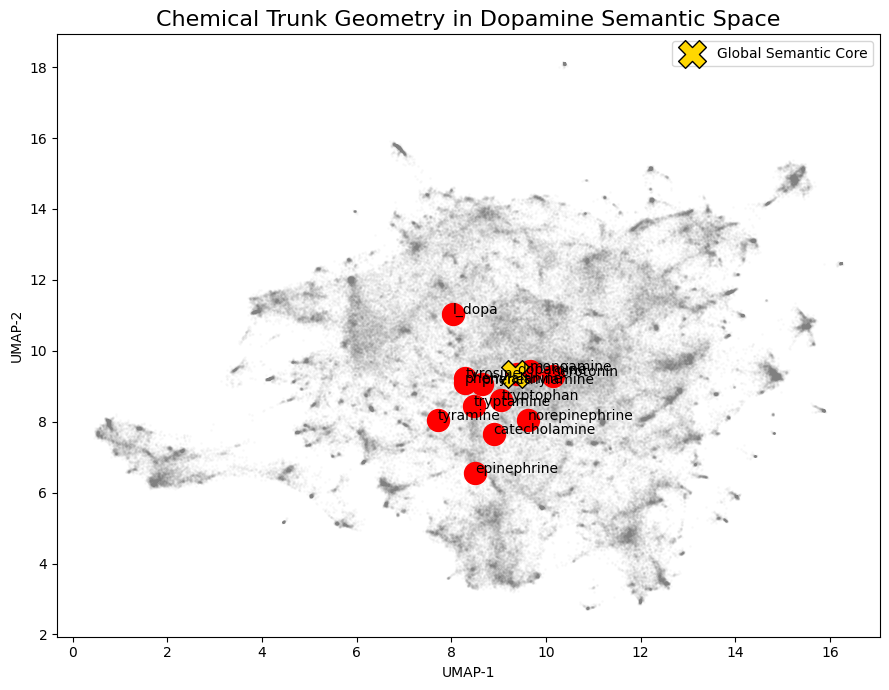


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_chemical_trunk_geometry_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_chemical_trunk_centroids_v001.csv


In [44]:
# =========================================================
# DOPAMINE TS_v001
# CHEMICAL TRUNK GEOMETRY IN SEMANTIC SPACE
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# ---------------------------------------------------------
# TEXT
# ---------------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# ---------------------------------------------------------
# TRUNK TERMS
# ---------------------------------------------------------

trunk_terms = {

    "dopamine":
        r"\bdopamine\b",

    "l_dopa":
        r"\bl[\-\s]?dopa\b|\blevodopa\b",

    "catecholamine":
        r"\bcatecholamine",

    "monoamine":
        r"\bmonoamine",

    "phenylalanine":
        r"\bphenylalanine\b",

    "tyrosine":
        r"\btyrosine\b",

    "tyramine":
        r"\btyramine\b",

    "phenethylamine":
        r"\bphenethylamine\b|\bpea\b",

    "norepinephrine":
        r"\bnorepinephrine\b|\bnoradrenaline\b",

    "epinephrine":
        r"\bepinephrine\b|\badrenaline\b",

    "tryptophan":
        r"\btryptophan\b",

    "tryptamine":
        r"\btryptamine\b",

    "serotonin":
        r"\bserotonin\b|\b5[\-\s]?ht\b"
}

# ---------------------------------------------------------
# CENTROIDS
# ---------------------------------------------------------

rows = []

for name, pattern in trunk_terms.items():

    subset = df[
        df["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ]

    n = len(subset)

    cx = subset["UMAP-1"].mean()
    cy = subset["UMAP-2"].mean()

    rows.append({
        "term": name,
        "n": n,
        "x": cx,
        "y": cy
    })

    print(
        f"{name}: n={n} "
        f"centroid=({cx:.3f}, {cy:.3f})"
    )

chem_df = pd.DataFrame(rows)

# ---------------------------------------------------------
# GLOBAL CORE
# ---------------------------------------------------------

global_x = df["UMAP-1"].mean()
global_y = df["UMAP-2"].mean()

chem_df["distance_to_global"] = np.sqrt(
    (chem_df["x"] - global_x)**2 +
    (chem_df["y"] - global_y)**2
)

# ---------------------------------------------------------
# SORT
# ---------------------------------------------------------

chem_df = chem_df.sort_values(
    "distance_to_global"
)

print("\n=== CLOSEST TO GLOBAL CORE ===")
print(
    chem_df[
        ["term", "distance_to_global", "n"]
    ]
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(9,7))

# background
plt.scatter(
    df["UMAP-1"],
    df["UMAP-2"],
    s=1,
    alpha=0.03,
    color="gray"
)

# chemicals
plt.scatter(
    chem_df["x"],
    chem_df["y"],
    s=250,
    color="red"
)

# labels
for _, row in chem_df.iterrows():

    plt.text(
        row["x"],
        row["y"],
        row["term"],
        fontsize=10
    )

# global centroid
plt.scatter(
    global_x,
    global_y,
    s=400,
    marker="X",
    color="gold",
    edgecolor="black",
    label="Global Semantic Core"
)

plt.title(
    "Chemical Trunk Geometry in Dopamine Semantic Space",
    fontsize=16
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend()
plt.tight_layout()

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

PNG = (
    f"{BASE}\\dopamine_chemical_trunk_geometry_v001.png"
)

CSV = (
    f"{BASE}\\dopamine_chemical_trunk_centroids_v001.csv"
)

plt.savefig(
    PNG,
    dpi=300
)

chem_df.to_csv(
    CSV,
    index=False
)

plt.show()

print("\nSaved:")
print(PNG)
print(CSV)


=== CLOSEST CHEMICALS TO FUNCTIONS ===

MOVEMENT
  l_dopa: 0.534
  tyrosine: 1.765
  dopamine: 1.835

INHIBITION
  monoamine: 0.300
  dopamine: 0.322
  serotonin: 0.530

REWARD
  serotonin: 2.183
  monoamine: 2.512
  dopamine: 2.783

SALIENCE
  serotonin: 2.502
  monoamine: 2.766
  dopamine: 3.028

COGNITION
  monoamine: 1.689
  serotonin: 1.783
  dopamine: 1.857

MOTIVATION
  serotonin: 1.734
  monoamine: 2.102
  dopamine: 2.376

EMOTION
  serotonin: 1.990
  monoamine: 2.266
  dopamine: 2.531

LEARNING
  serotonin: 1.424
  monoamine: 1.510
  dopamine: 1.743

ADDICTION
  serotonin: 2.632
  monoamine: 3.006
  dopamine: 3.280

SCHIZOPHRENIA
  serotonin: 2.470
  monoamine: 2.696
  dopamine: 2.951


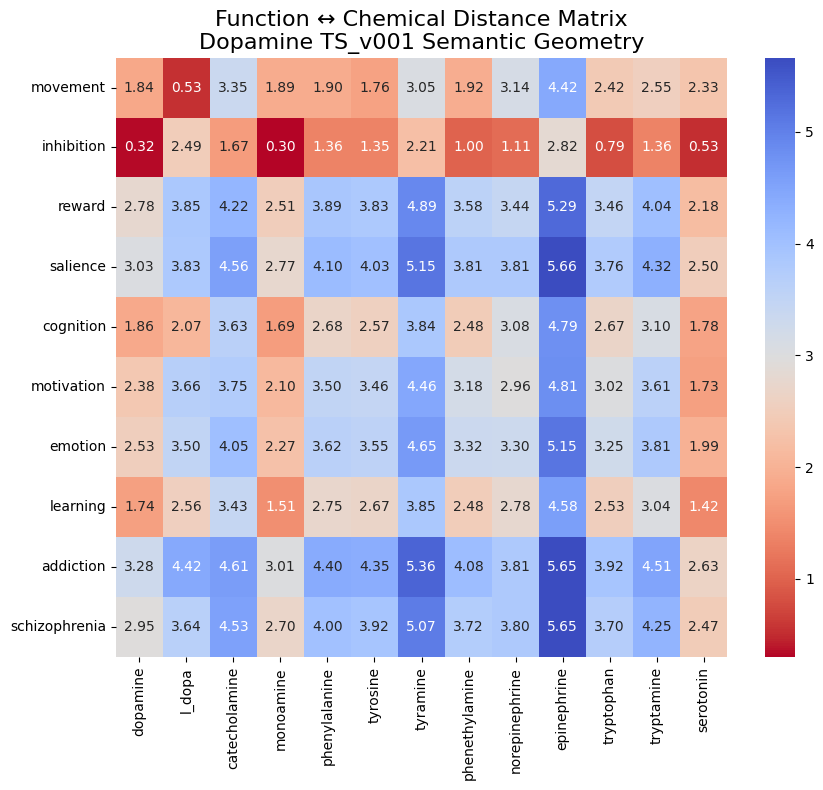


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_function_chemical_distance_heatmap_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_function_chemical_distances_v001.csv


In [45]:
# =========================================================
# FUNCTION ↔ CHEMICAL DISTANCE MATRIX
# TS_v001
# =========================================================

import pandas as pd
import numpy as np
from scipy.spatial.distance import euclidean
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# LOAD
# ---------------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

df = pd.read_csv(
    f"{BASE}\\dopamine_TS_master_v001.csv"
)

# ---------------------------------------------------------
# TEXT
# ---------------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# ---------------------------------------------------------
# FUNCTIONS
# ---------------------------------------------------------

functions = {

    "movement":
        r"\bmotor\b|movement|locomot|parkinson",

    "inhibition":
        r"\binhibition\b|response suppression",

    "reward":
        r"\breward\b|reinforcement",

    "salience":
        r"\bsalience\b",

    "cognition":
        r"cognit|attention|executive|memory",

    "motivation":
        r"\bmotiv",

    "emotion":
        r"\bemotion\b|affective",

    "learning":
        r"\blearning\b|conditioning",

    "addiction":
        r"addict|substance use|drug seeking",

    "schizophrenia":
        r"schizophrenia|psychosis"
}

# ---------------------------------------------------------
# CHEMICALS
# ---------------------------------------------------------

chemicals = {

    "dopamine":
        r"\bdopamine\b",

    "l_dopa":
        r"\bl[\-\s]?dopa\b|\blevodopa\b",

    "catecholamine":
        r"\bcatecholamine",

    "monoamine":
        r"\bmonoamine",

    "phenylalanine":
        r"\bphenylalanine\b",

    "tyrosine":
        r"\btyrosine\b",

    "tyramine":
        r"\btyramine\b",

    "phenethylamine":
        r"\bphenethylamine\b|\bpea\b",

    "norepinephrine":
        r"\bnorepinephrine\b|\bnoradrenaline\b",

    "epinephrine":
        r"\bepinephrine\b|\badrenaline\b",

    "tryptophan":
        r"\btryptophan\b",

    "tryptamine":
        r"\btryptamine\b",

    "serotonin":
        r"\bserotonin\b|\b5[\-\s]?ht\b"
}

# ---------------------------------------------------------
# FUNCTION CENTROIDS
# ---------------------------------------------------------

func_centroids = {}

for name, pattern in functions.items():

    subset = df[
        df["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ]

    func_centroids[name] = np.array([
        subset["UMAP-1"].mean(),
        subset["UMAP-2"].mean()
    ])

# ---------------------------------------------------------
# CHEMICAL CENTROIDS
# ---------------------------------------------------------

chem_centroids = {}

for name, pattern in chemicals.items():

    subset = df[
        df["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ]

    chem_centroids[name] = np.array([
        subset["UMAP-1"].mean(),
        subset["UMAP-2"].mean()
    ])

# ---------------------------------------------------------
# DISTANCE MATRIX
# ---------------------------------------------------------

matrix = pd.DataFrame(
    index=functions.keys(),
    columns=chemicals.keys()
)

for f_name, f_vec in func_centroids.items():

    for c_name, c_vec in chem_centroids.items():

        dist = euclidean(f_vec, c_vec)

        matrix.loc[f_name, c_name] = dist

matrix = matrix.astype(float)

# ---------------------------------------------------------
# PRINT CLOSEST CHEMICAL FOR EACH FUNCTION
# ---------------------------------------------------------

summary = []

print("\n=== CLOSEST CHEMICALS TO FUNCTIONS ===")

for func in matrix.index:

    closest = matrix.loc[func].sort_values().head(3)

    print(f"\n{func.upper()}")

    for chem, dist in closest.items():

        print(f"  {chem}: {dist:.3f}")

        summary.append({
            "function": func,
            "chemical": chem,
            "distance": dist
        })

summary_df = pd.DataFrame(summary)

# ---------------------------------------------------------
# HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(9,8))

sns.heatmap(
    matrix,
    cmap="coolwarm_r",
    annot=True,
    fmt=".2f"
)

plt.title(
    "Function ↔ Chemical Distance Matrix\nDopamine TS_v001 Semantic Geometry",
    fontsize=16
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

PNG = (
    f"{BASE}\\dopamine_function_chemical_distance_heatmap_v001.png"
)

CSV = (
    f"{BASE}\\dopamine_function_chemical_distances_v001.csv"
)

plt.savefig(
    PNG,
    dpi=300
)

matrix.to_csv(CSV)

plt.show()

print("\nSaved:")
print(PNG)
print(CSV)

Matrix shape: (10, 13)

=== TS PERMUTATION RESULTS ===
Real mean correlation: 0.8814
Null mean correlation: 0.1003
p-value: 0.0
Z-score: 20.435


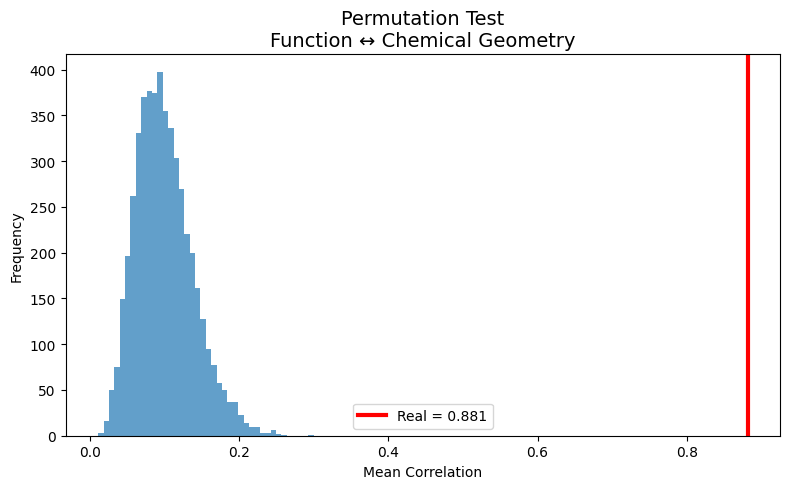


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_geometry_permutation_test_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_geometry_permutation_stats_v001.csv


In [46]:
# =========================================================
# TS_v001
# PERMUTATION TEST ON FUNCTION ↔ CHEMICAL GEOMETRY
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# LOAD DISTANCE MATRIX
# ---------------------------------------------------------

BASE = r"C:\neurofeedback_models\dopamine_20251202\TS_v001"

dist_df = pd.read_csv(
    f"{BASE}\\dopamine_function_chemical_distances_v001.csv",
    index_col=0
)

# ---------------------------------------------------------
# MATRIX
# rows = functions
# cols = chemicals
# ---------------------------------------------------------

X = dist_df.values

print("Matrix shape:", X.shape)

# =========================================================
# PERMUTATION TEST
# =========================================================

def perm_test(X, n_perm=5000):

    # ---------------------------------------------
    # REAL STRUCTURE
    # ---------------------------------------------

    corr_real = np.corrcoef(X)

    real_mean_corr = np.mean(corr_real)

    # ---------------------------------------------
    # NULL
    # ---------------------------------------------

    perm_corrs = []

    for _ in range(n_perm):

        X_perm = X.copy()

        # shuffle EACH FUNCTION ROW
        for i in range(X_perm.shape[0]):

            np.random.shuffle(X_perm[i])

        corr_perm = np.corrcoef(X_perm)

        perm_corrs.append(
            np.mean(corr_perm)
        )

    perm_corrs = np.array(perm_corrs)

    # ---------------------------------------------
    # P VALUE
    # ---------------------------------------------

    p_val = np.mean(
        perm_corrs >= real_mean_corr
    )

    return (
        real_mean_corr,
        perm_corrs.mean(),
        p_val,
        perm_corrs
    )

# =========================================================
# RUN
# =========================================================

real_corr, null_corr, p_val, perm_dist = perm_test(X)

# =========================================================
# RESULTS
# =========================================================

print("\n=== TS PERMUTATION RESULTS ===")

print(
    "Real mean correlation:",
    round(real_corr, 4)
)

print(
    "Null mean correlation:",
    round(null_corr, 4)
)

print(
    "p-value:",
    p_val
)

# =========================================================
# EFFECT SIZE
# =========================================================

z_score = (
    (real_corr - perm_dist.mean())
    / perm_dist.std()
)

print(
    "Z-score:",
    round(z_score, 3)
)

# =========================================================
# HISTOGRAM
# =========================================================

plt.figure(figsize=(8,5))

plt.hist(
    perm_dist,
    bins=40,
    alpha=0.7
)

plt.axvline(
    real_corr,
    color="red",
    linewidth=3,
    label=f"Real = {real_corr:.3f}"
)

plt.title(
    "Permutation Test\nFunction ↔ Chemical Geometry",
    fontsize=14
)

plt.xlabel("Mean Correlation")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

PNG = (
    f"{BASE}\\dopamine_geometry_permutation_test_v001.png"
)

OUT = pd.DataFrame({
    "real_corr": [real_corr],
    "null_mean": [null_corr],
    "p_value": [p_val],
    "z_score": [z_score]
})

CSV = (
    f"{BASE}\\dopamine_geometry_permutation_stats_v001.csv"
)

plt.savefig(
    PNG,
    dpi=300
)

OUT.to_csv(
    CSV,
    index=False
)

plt.show()

print("\nSaved:")
print(PNG)
print(CSV)

In [47]:
# =========================================================
# TS_v001
# FUNCTIONAL vs CHEMICAL SPREAD
# =========================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist

# ---------------------------------------------------------
# FUNCTION CENTROIDS
# ---------------------------------------------------------

func_keys = [
    "movement",
    "reward",
    "cognition",
    "learning",
    "inhibition",
    "emotion",
    "salience",
    "motivation",
    "addiction",
    "schizophrenia"
]

# ---------------------------------------------------------
# CHEMICAL CENTROIDS
# ---------------------------------------------------------

chem_keys = [
    "dopamine",
    "l_dopa",
    "catecholamine",
    "monoamine",
    "phenylalanine",
    "tyrosine",
    "tyramine",
    "phenethylamine",
    "norepinephrine",
    "epinephrine",
    "tryptamine",
    "tryptophan",
    "serotonin"
]

# ---------------------------------------------------------
# BUILD MATRICES
# uses existing centroid dicts:
# func_centroids
# chem_centroids
# ---------------------------------------------------------

func_X = np.vstack([
    func_centroids[k]
    for k in func_keys
])

chem_X = np.vstack([
    chem_centroids[k]
    for k in chem_keys
])

# ---------------------------------------------------------
# SPREAD
# ---------------------------------------------------------

func_spread = np.mean(
    pdist(func_X)
)

chem_spread = np.mean(
    pdist(chem_X)
)

print("\n=== SEMANTIC SPREAD ===")

print(
    "Functional spread:",
    round(func_spread, 4)
)

print(
    "Chemical spread:",
    round(chem_spread, 4)
)

# ---------------------------------------------------------
# RATIO
# ---------------------------------------------------------

spread_ratio = (
    func_spread /
    chem_spread
)

print(
    "Function/Chemical ratio:",
    round(spread_ratio, 4)
)

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

if spread_ratio > 1:

    print(
        "\nInterpretation:"
    )

    print(
        "Functional semantic space "
        "is more dispersed than "
        "chemical trunk space."
    )

else:

    print(
        "\nInterpretation:"
    )

    print(
        "Chemical trunk space "
        "is more dispersed than "
        "functional semantic space."
    )

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

spread_df = pd.DataFrame({

    "functional_spread":
        [func_spread],

    "chemical_spread":
        [chem_spread],

    "spread_ratio":
        [spread_ratio]
})

OUT = (
    r"C:\neurofeedback_models\dopamine_20251202\TS_v001"
    r"\dopamine_semantic_spread_stats_v001.csv"
)

spread_df.to_csv(
    OUT,
    index=False
)

print("\nSaved:")
print(OUT)


=== SEMANTIC SPREAD ===
Functional spread: 1.6566
Chemical spread: 1.6274
Function/Chemical ratio: 1.018

Interpretation:
Functional semantic space is more dispersed than chemical trunk space.

Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\dopamine_semantic_spread_stats_v001.csv


Using existing df: (157573, 11)

MOVEMENT TOP TERMS (43944 papers):
['dopamine', 'disease', 'parkinson', 'dopaminergic', 'neurons', 'patients', 'motor', 'activity', 'rats', 'mice', 'receptor', 'brain', 'which', 'after', 'striatal', 'cells', 'also', 'model', 'receptors', 'striatum', 'both', 'expression', 'between', 'locomotor', 'role']

REWARD TOP TERMS (10664 papers):
['dopamine', 'reward', 'neurons', 'rats', 'receptor', 'brain', 'cocaine', 'learning', 'dopaminergic', 'behavior', 'which', 'activity', 'system', 'nucleus', 'role', 'mice', 'during', 'receptors', 'reinforcement', 'accumbens', 'between', 'both', 'also', 'drug', 'ventral']

COGNITION TOP TERMS (14990 papers):
['dopamine', 'cognitive', 'memory', 'patients', 'brain', 'disease', 'receptor', 'dopaminergic', 'which', 'rats', 'between', 'activity', 'receptors', 'learning', 'also', 'mice', 'schizophrenia', 'parkinson', 'function', 'neurons', 'cortex', 'symptoms', 'motor', 'role', 'both']

LEARNING TOP TERMS (7673 papers):
['dopamin

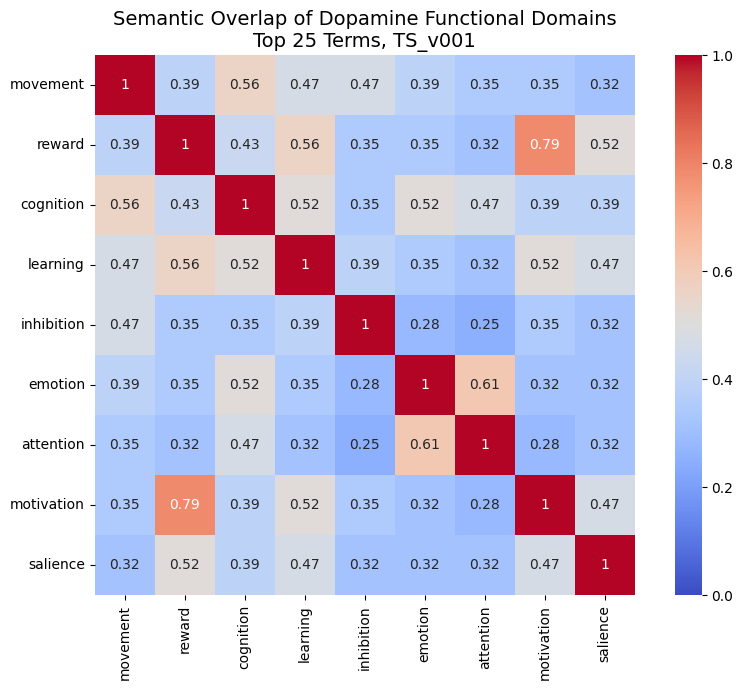


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_domain_word_overlap_top25_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_domain_word_overlap_top25_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_domain_top25_terms_v001.csv


In [48]:
# =========================================================
# TS_v001 FUNCTIONAL DOMAIN WORD OVERLAP
# Top 25 Terms + Jaccard Similarity
# =========================================================

import re
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# PATH
# ---------------------------------------------------------

BASE = Path(r"C:\neurofeedback_models\dopamine_20251202\TS_v001")
OUT_DIR = BASE / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# LOAD IF NEEDED
# ---------------------------------------------------------

try:
    df
    print("Using existing df:", df.shape)
except NameError:
    df = pd.read_csv(BASE / "dopamine_TS_master_v001.csv")
    print("Loaded df:", df.shape)

# ---------------------------------------------------------
# TEXT
# ---------------------------------------------------------

df["text_lower"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

# ---------------------------------------------------------
# STOPWORDS
# keep domain scaffold terms like brain, receptor, motor, dopamine
# remove only weak generic/reporting words
# ---------------------------------------------------------

STOPWORDS = set([
    "the","and","of","in","to","a","for","with","on","by","is","are",
    "that","from","as","at","an","be","this","these","those","it",
    "we","our","their","has","have","had","was","were","been","being",
    "using","used","use","study","studies","results","result","method",
    "methods","show","shows","shown","suggest","suggests","suggested",
    "including","compared","significant","significantly","effect","effects",
    "increase","increased","decrease","decreased","level","levels",
    "group","groups","control","controls","treatment","treated",
    "different","various","associated","analysis","data"
])

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s\-]", " ", text)
    words = text.split()
    return [
        w for w in words
        if w not in STOPWORDS
        and len(w) > 3
    ]

def get_mask(term_patterns):
    pattern = "|".join(term_patterns)
    return df["text_lower"].str.contains(pattern, regex=True, na=False)

# ---------------------------------------------------------
# FUNCTIONAL DOMAINS
# regex patterns, not just literal terms
# ---------------------------------------------------------

DOMAIN_TERMS = {
    "movement": [
        r"\bmotor\b",
        r"\bmovement\b",
        r"locomot",
        r"parkinson"
    ],

    "reward": [
        r"\breward\b",
        r"reinforcement",
        r"hedonic"
    ],

    "cognition": [
        r"cognit",
        r"executive",
        r"\bmemory\b"
    ],

    "learning": [
        r"\blearning\b",
        r"conditioning"
    ],

    "inhibition": [
        r"\binhibition\b",
        r"inhibitory",
        r"response suppression"
    ],

    "emotion": [
        r"\bemotion\b",
        r"affective",
        r"\bmood\b"
    ],

    "attention": [
        r"\battention\b",
        r"attentional"
    ],

    "motivation": [
        r"\bmotivation\b",
        r"motivational",
        r"incentive"
    ],

    "salience": [
        r"\bsalience\b",
        r"salient"
    ]
}

# ---------------------------------------------------------
# TOP TERMS PER DOMAIN
# ---------------------------------------------------------

domain_top_terms = {}
domain_counts = []

for domain, patterns in DOMAIN_TERMS.items():

    mask = get_mask(patterns)

    texts = (
        df.loc[mask, "title"].fillna("") + " " +
        df.loc[mask, "abstract"].fillna("")
    )

    all_words = []

    for t in texts:
        all_words.extend(tokenize(t))

    counts = Counter(all_words)
    top = counts.most_common(25)

    domain_top_terms[domain] = [w for w, c in top]

    domain_counts.append({
        "domain": domain,
        "n_papers": int(mask.sum()),
        "top_terms": ", ".join(domain_top_terms[domain])
    })

    print(f"\n{domain.upper()} TOP TERMS ({int(mask.sum())} papers):")
    print(domain_top_terms[domain])

domain_terms_df = pd.DataFrame(domain_counts)

# ---------------------------------------------------------
# JACCARD OVERLAP MATRIX
# ---------------------------------------------------------

domains = list(domain_top_terms.keys())

overlap = pd.DataFrame(
    index=domains,
    columns=domains,
    dtype=float
)

for d1 in domains:
    for d2 in domains:

        set1 = set(domain_top_terms[d1])
        set2 = set(domain_top_terms[d2])

        jaccard = (
            len(set1 & set2) /
            len(set1 | set2)
            if len(set1 | set2) > 0
            else 0
        )

        overlap.loc[d1, d2] = round(jaccard, 3)

print("\n=== FUNCTIONAL DOMAIN WORD OVERLAP ===")
print(overlap)

# ---------------------------------------------------------
# HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(9, 7))

sns.heatmap(
    overlap.astype(float),
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    square=True
)

plt.title(
    "Semantic Overlap of Dopamine Functional Domains\nTop 25 Terms, TS_v001",
    fontsize=14
)

plt.tight_layout()

PNG = OUT_DIR / "dopamine_domain_word_overlap_top25_v001.png"
CSV_OVERLAP = OUT_DIR / "dopamine_domain_word_overlap_top25_v001.csv"
CSV_TERMS = OUT_DIR / "dopamine_domain_top25_terms_v001.csv"

plt.savefig(PNG, dpi=300)
plt.show()

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

overlap.to_csv(CSV_OVERLAP)
domain_terms_df.to_csv(CSV_TERMS, index=False)

print("\nSaved:")
print(PNG)
print(CSV_OVERLAP)
print(CSV_TERMS)


=== PAIRWISE SHARED % ===
            movement  reward  cognition  learning  inhibition  emotion  \
movement        1.00    0.56       0.72      0.64        0.64     0.56   
reward          0.56    1.00       0.60      0.72        0.52     0.52   
cognition       0.72    0.60       1.00      0.68        0.52     0.68   
learning        0.64    0.72       0.68      1.00        0.56     0.52   
inhibition      0.64    0.52       0.52      0.56        1.00     0.44   
emotion         0.56    0.52       0.68      0.52        0.44     1.00   
attention       0.52    0.48       0.64      0.48        0.40     0.76   
motivation      0.52    0.88       0.56      0.68        0.52     0.48   
salience        0.48    0.68       0.56      0.64        0.48     0.48   

            attention  motivation  salience  
movement         0.52        0.52      0.48  
reward           0.48        0.88      0.68  
cognition        0.64        0.56      0.56  
learning         0.48        0.68      0.64  
in

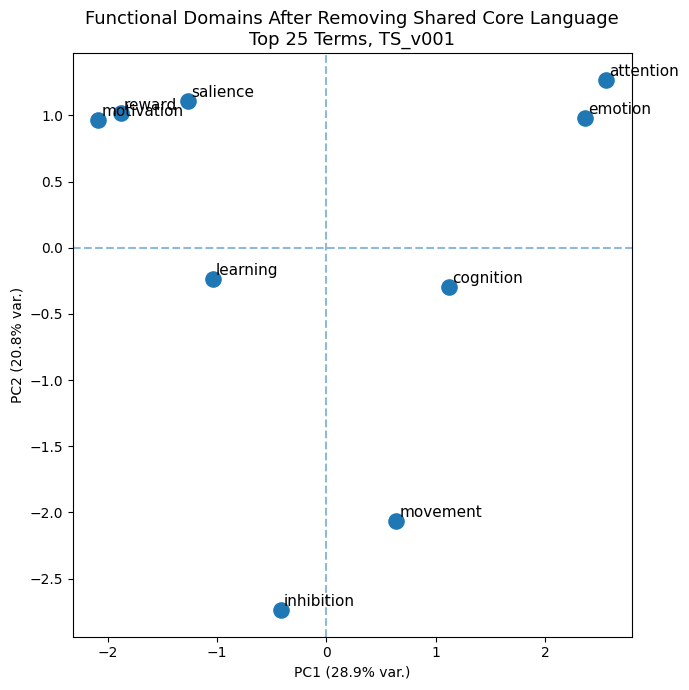


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_functional_partial_space_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_pairwise_shared_percent_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_domain_term_matrix_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_domain_term_matrix_partial_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_functional_partial_pca_coords_v001.csv


In [49]:
# =========================================================
# TS_v001 — PARTIAL FUNCTIONAL LANGUAGE SPACE
# Pairwise Shared %, Domain × Term Matrix, Core Removal, PCA
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

# ---------------------------------------------------------
# PATH
# ---------------------------------------------------------

BASE = Path(r"C:\neurofeedback_models\dopamine_20251202\TS_v001")
OUT_DIR = BASE / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# DOMAIN SETS
# requires domain_top_terms from prior cell
# ---------------------------------------------------------

domain_sets = {
    k: set(v)
    for k, v in domain_top_terms.items()
}

domain_names = list(domain_sets.keys())

all_terms = set().union(*domain_sets.values())
shared_terms = set.intersection(*domain_sets.values())

# ---------------------------------------------------------
# PAIRWISE SHARED %
# directional: % of d1 terms present in d2
# ---------------------------------------------------------

pairwise_shared = pd.DataFrame(
    index=domain_names,
    columns=domain_names,
    dtype=float
)

for d1 in domain_names:
    for d2 in domain_names:
        s1 = domain_sets[d1]
        s2 = domain_sets[d2]

        val = len(s1 & s2) / len(s1) if len(s1) else 0
        pairwise_shared.loc[d1, d2] = round(val, 3)

print("\n=== PAIRWISE SHARED % ===")
print(pairwise_shared)

# ---------------------------------------------------------
# DOMAIN × TERM MATRIX
# ---------------------------------------------------------

terms_list = sorted(all_terms)

matrix = pd.DataFrame(
    0,
    index=domain_names,
    columns=terms_list
)

for d in domain_names:
    for term in domain_sets[d]:
        matrix.loc[d, term] = 1

print("\nOriginal domain × term matrix:", matrix.shape)

# ---------------------------------------------------------
# REMOVE FULLY SHARED CORE
# ---------------------------------------------------------

core_terms = sorted(shared_terms)

matrix_partial = matrix.drop(
    columns=core_terms,
    errors="ignore"
)

print("Shared core terms:", core_terms)
print("After removing shared core:", matrix_partial.shape)

# ---------------------------------------------------------
# PCA ON PARTIAL MATRIX
# ---------------------------------------------------------

pca = PCA(n_components=2)

coords = pca.fit_transform(
    matrix_partial.values
)

pca_df = pd.DataFrame(
    coords,
    index=domain_names,
    columns=["PC1", "PC2"]
)

explained = pca.explained_variance_ratio_

print("\nExplained variance ratio:")
print(explained)

print("\n=== PCA COORDS ===")
print(pca_df)

# ---------------------------------------------------------
# PLOT PARTIAL SPACE
# ---------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=120
)

for domain in pca_df.index:
    plt.text(
        pca_df.loc[domain, "PC1"] + 0.03,
        pca_df.loc[domain, "PC2"] + 0.03,
        domain,
        fontsize=11
    )

plt.axhline(0, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

plt.title(
    "Functional Domains After Removing Shared Core Language\nTop 25 Terms, TS_v001",
    fontsize=13
)

plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var.)")

plt.tight_layout()

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

PNG = OUT_DIR / "dopamine_functional_partial_space_v001.png"
CSV_PAIRWISE = OUT_DIR / "dopamine_pairwise_shared_percent_v001.csv"
CSV_MATRIX = OUT_DIR / "dopamine_domain_term_matrix_v001.csv"
CSV_PARTIAL = OUT_DIR / "dopamine_domain_term_matrix_partial_v001.csv"
CSV_PCA = OUT_DIR / "dopamine_functional_partial_pca_coords_v001.csv"

plt.savefig(PNG, dpi=300)
plt.show()

pairwise_shared.to_csv(CSV_PAIRWISE)
matrix.to_csv(CSV_MATRIX)
matrix_partial.to_csv(CSV_PARTIAL)
pca_df.to_csv(CSV_PCA)

print("\nSaved:")
print(PNG)
print(CSV_PAIRWISE)
print(CSV_MATRIX)
print(CSV_PARTIAL)
print(CSV_PCA)

In [50]:
# =========================================================
# TS_v001 — SEMANTIC GRAVITY INDEX (FIXED)
# =========================================================

from scipy.spatial.distance import pdist
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# FUNCTION KEYS
# ---------------------------------------------------------

func_keys = [
    "movement",
    "reward",
    "cognition",
    "learning",
    "inhibition",
    "emotion",
    "attention",
    "motivation",
    "salience"
]

# ---------------------------------------------------------
# FULL SPACE
# use pairwise overlap matrix as full semantic structure
# ---------------------------------------------------------

X_full = overlap.loc[
    func_keys,
    func_keys
].astype(float).values

dist_full = pdist(X_full).mean()

# ---------------------------------------------------------
# PARTIAL SPACE
# PCA coordinates after removing shared language
# ---------------------------------------------------------

X_partial = pca_df.loc[
    func_keys
].values

dist_partial = pdist(X_partial).mean()

# ---------------------------------------------------------
# SGI
# ---------------------------------------------------------

SGI = 1 - (dist_full / dist_partial)

# ---------------------------------------------------------
# OUTPUT
# ---------------------------------------------------------

print("\n====================================")
print("SEMANTIC GRAVITY INDEX (TS_v001)")
print("====================================\n")

print("Mean distance (FULL overlap space):")
print(round(dist_full, 4))

print("\nMean distance (PARTIAL core-removed space):")
print(round(dist_partial, 4))

print("\nSemantic Gravity Index (SGI):")
print(round(SGI, 4))

# ---------------------------------------------------------
# INTERPRETATION
# ---------------------------------------------------------

print("\n====================================")
print("INTERPRETATION")
print("====================================\n")

if SGI > 0.50:
    print(
        "Strong semantic gravity:\n"
        "shared dopamine language heavily compresses functional domains."
    )

elif SGI > 0.25:
    print(
        "Moderate semantic gravity:\n"
        "shared language substantially contributes to cohesion."
    )

elif SGI > 0:
    print(
        "Weak semantic gravity:\n"
        "domains retain strong independent structure."
    )

else:
    print(
        "Negative SGI:\n"
        "domains become MORE compressed after removing shared language."
    )

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

sgi_df = pd.DataFrame({
    "metric": [
        "mean_distance_full",
        "mean_distance_partial",
        "semantic_gravity_index"
    ],
    "value": [
        dist_full,
        dist_partial,
        SGI
    ]
})

OUT = (
    BASE
    / "analysis"
    / "dopamine_semantic_gravity_index_v001.csv"
)

sgi_df.to_csv(OUT, index=False)

print("\nSaved:")
print(OUT)


SEMANTIC GRAVITY INDEX (TS_v001)

Mean distance (FULL overlap space):
0.924

Mean distance (PARTIAL core-removed space):
2.9624

Semantic Gravity Index (SGI):
0.6881

INTERPRETATION

Strong semantic gravity:
shared dopamine language heavily compresses functional domains.

Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_semantic_gravity_index_v001.csv


In [51]:
# =========================================================
# TS_v001 — VARIANCE COMPRESSION
# IDENTITY LOSS
# SEMANTIC CENTER ANALYSIS
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ---------------------------------------------------------
# FUNCTION KEYS
# ---------------------------------------------------------

func_keys = [
    "movement",
    "reward",
    "cognition",
    "learning",
    "inhibition",
    "emotion",
    "attention",
    "motivation",
    "salience"
]

# ---------------------------------------------------------
# FULL SPACE
# overlap matrix representation
# ---------------------------------------------------------

X_full = overlap.loc[
    func_keys,
    func_keys
].astype(float).values

# ---------------------------------------------------------
# PARTIAL SPACE
# PCA coordinates after shared-language removal
# ---------------------------------------------------------

X_partial = pca_df.loc[
    func_keys
].values

# =========================================================
# VARIANCE COMPRESSION
# =========================================================

var_full = np.var(
    X_full,
    axis=0
).sum()

var_partial = np.var(
    X_partial,
    axis=0
).sum()

compression = 1 - (var_full / var_partial)

print("\n====================================")
print("VARIANCE COMPRESSION")
print("====================================\n")

print("Variance FULL space:")
print(round(var_full, 4))

print("\nVariance PARTIAL space:")
print(round(var_partial, 4))

print("\nVariance Compression:")
print(round(compression, 4))

# =========================================================
# IDENTITY LOSS
# =========================================================
#
# compares relational structure before vs after
# removing shared language
#
# high value:
# shared language heavily alters identity geometry
#
# low value:
# structure remains stable after removal
#
# =========================================================

sim_full = cosine_similarity(X_full)

sim_partial = cosine_similarity(X_partial)

identity_loss = np.mean(
    np.abs(sim_full - sim_partial)
)

print("\n====================================")
print("IDENTITY LOSS")
print("====================================\n")

print("Identity loss:")
print(round(identity_loss, 4))

# =========================================================
# SEMANTIC CENTER ANALYSIS
# =========================================================

center = X_full.mean(axis=0)

dist_to_center = np.linalg.norm(
    X_full - center,
    axis=1
)

center_df = pd.DataFrame({
    "domain": func_keys,
    "distance_to_center": dist_to_center
})

center_df = center_df.sort_values(
    "distance_to_center"
)

print("\n====================================")
print("SEMANTIC CENTER ANALYSIS")
print("====================================\n")

print(center_df.to_string(index=False))

print("\nMean distance to center:")
print(round(dist_to_center.mean(), 4))

print("\nStd distance:")
print(round(dist_to_center.std(), 4))

# =========================================================
# INTERPRETATION
# =========================================================

print("\n====================================")
print("TS INTERPRETATION")
print("====================================\n")

if compression > 0.50:
    print(
        "Strong semantic compression detected:\n"
        "shared dopamine language substantially reduces domain variance."
    )

elif compression > 0.25:
    print(
        "Moderate semantic compression detected."
    )

else:
    print(
        "Weak semantic compression detected."
    )

if identity_loss > 0.40:
    print(
        "\nHigh identity loss:\n"
        "shared language strongly alters functional geometry."
    )

elif identity_loss > 0.20:
    print(
        "\nModerate identity loss:\n"
        "partial structural reorganization after core removal."
    )

else:
    print(
        "\nLow identity loss:\n"
        "domain relations remain stable after removing core language."
    )

# =========================================================
# SAVE
# =========================================================

summary_df = pd.DataFrame({
    "metric": [
        "variance_full",
        "variance_partial",
        "variance_compression",
        "identity_loss",
        "mean_distance_to_center",
        "std_distance_to_center"
    ],
    "value": [
        var_full,
        var_partial,
        compression,
        identity_loss,
        dist_to_center.mean(),
        dist_to_center.std()
    ]
})

OUT1 = (
    BASE
    / "analysis"
    / "dopamine_TS_metrics_v001.csv"
)

OUT2 = (
    BASE
    / "analysis"
    / "dopamine_semantic_center_distances_v001.csv"
)

summary_df.to_csv(OUT1, index=False)

center_df.to_csv(OUT2, index=False)

print("\nSaved:")
print(OUT1)
print(OUT2)


VARIANCE COMPRESSION

Variance FULL space:
0.3951

Variance PARTIAL space:
4.6937

Variance Compression:
0.9158

IDENTITY LOSS

Identity loss:
0.849

SEMANTIC CENTER ANALYSIS

    domain  distance_to_center
  learning            0.518677
 cognition            0.526652
  movement            0.591470
    reward            0.603438
  salience            0.619762
motivation            0.635747
   emotion            0.676093
inhibition            0.718022
 attention            0.731089

Mean distance to center:
0.6246

Std distance:
0.0709

TS INTERPRETATION

Strong semantic compression detected:
shared dopamine language substantially reduces domain variance.

High identity loss:
shared language strongly alters functional geometry.

Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_TS_metrics_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_semantic_center_distances_v001.csv


In [52]:
# =========================================================
# TS_v001 — SEMANTIC CENTER STABILITY
# Full Space vs Core-Removed Partial Space
# =========================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# FUNCTION KEYS
# ---------------------------------------------------------

func_keys = [
    "movement",
    "reward",
    "cognition",
    "learning",
    "inhibition",
    "emotion",
    "attention",
    "motivation",
    "salience"
]

# ---------------------------------------------------------
# FULL SPACE
# overlap geometry
# ---------------------------------------------------------

X_full_func = overlap.loc[
    func_keys,
    func_keys
].astype(float).values

# ---------------------------------------------------------
# PARTIAL SPACE
# PCA after removing shared scaffold
# ---------------------------------------------------------

X_partial_func = pca_df.loc[
    func_keys
].values

# =========================================================
# CENTER CALCULATION
# =========================================================

center_full = X_full_func.mean(axis=0)

center_partial = X_partial_func.mean(axis=0)

# =========================================================
# DISTANCE TO CENTER
# =========================================================

dist_full = np.linalg.norm(
    X_full_func - center_full,
    axis=1
)

dist_partial = np.linalg.norm(
    X_partial_func - center_partial,
    axis=1
)

# ---------------------------------------------------------
# MEANS
# ---------------------------------------------------------

mean_full = dist_full.mean()

mean_partial = dist_partial.mean()

# ---------------------------------------------------------
# EXPANSION RATIO
# ---------------------------------------------------------

expansion_ratio = (
    mean_partial /
    mean_full
)

# =========================================================
# OUTPUT
# =========================================================

print("\n====================================")
print("SEMANTIC CENTER STABILITY")
print("====================================\n")

print("Mean distance to center (FULL):")
print(round(mean_full, 4))

print("\nMean distance to center (PARTIAL):")
print(round(mean_partial, 4))

print("\nExpansion ratio:")
print(round(expansion_ratio, 4))

# =========================================================
# DOMAIN-LEVEL TABLE
# =========================================================

center_compare = pd.DataFrame({
    "domain": func_keys,
    "dist_full": dist_full,
    "dist_partial": dist_partial
})

center_compare["delta"] = (
    center_compare["dist_partial"]
    - center_compare["dist_full"]
)

center_compare = center_compare.sort_values(
    "delta",
    ascending=False
)

print("\n====================================")
print("DOMAIN EXPANSION AFTER CORE REMOVAL")
print("====================================\n")

print(center_compare.to_string(index=False))

# =========================================================
# INTERPRETATION
# =========================================================

print("\n====================================")
print("TS INTERPRETATION")
print("====================================\n")

if expansion_ratio > 2:
    print(
        "Strong latent divergence:\n"
        "domains separate substantially after removing shared language."
    )

elif expansion_ratio > 1.25:
    print(
        "Moderate latent divergence detected."
    )

else:
    print(
        "Weak latent divergence detected."
    )

# =========================================================
# SAVE
# =========================================================

OUT = (
    BASE
    / "analysis"
    / "dopamine_semantic_center_stability_v001.csv"
)

center_compare.to_csv(
    OUT,
    index=False
)

print("\nSaved:")
print(OUT)


SEMANTIC CENTER STABILITY

Mean distance to center (FULL):
0.6246

Mean distance to center (PARTIAL):
2.0773

Expansion ratio:
3.3261

DOMAIN EXPANSION AFTER CORE REMOVAL

    domain  dist_full  dist_partial    delta
 attention   0.731089      2.859699 2.128610
inhibition   0.718022      2.770130 2.052108
   emotion   0.676093      2.560826 1.884733
motivation   0.635747      2.297199 1.661452
  movement   0.591470      2.162961 1.571491
    reward   0.603438      2.138506 1.535068
  salience   0.619762      1.679617 1.059855
 cognition   0.526652      1.160067 0.633415
  learning   0.518677      1.067114 0.548437

TS INTERPRETATION

Strong latent divergence:
domains separate substantially after removing shared language.

Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_semantic_center_stability_v001.csv


Loaded: (157573, 10)
Strict / validation count: 9290

=== RECEPTOR SPECIFICATION ===
   has_receptor  count   percent
0         False   9768  0.852728
1          True   1687  0.147272

=== RECEPTOR × DOMAIN ===
   receptors      domain  count
53      none       other   3944
52      none       motor   2465
49      none  inhibition    951
47      none   cognition    842
54      none      reward    415
50      none    learning    397
46      none   attention    370
17        D2       other    364
48      none     emotion    197
51      none  motivation    147
16        D2       motor    137
7         D1       other    111
27        D3       other    104
13        D2  inhibition     97
36        D4       other     94
6         D1       motor     73
29        D4   attention     66
11        D2   cognition     65
18        D2      reward     61
26        D3       motor     44
1         D1   cognition     41
55      none    salience     40
14        D2    learning     37
10        D2   attent

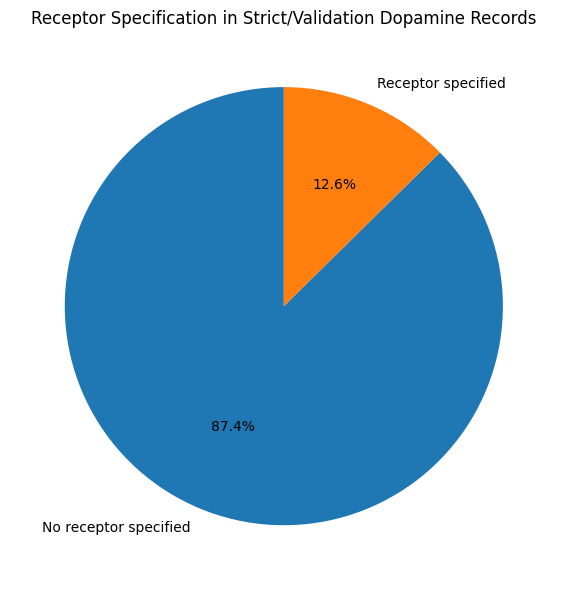


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_strict_validation_receptor_records_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_specification_strict_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_domain_strict_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_outcomes_strict_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_decade_strict_v001.csv
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\fig_dopamine_receptor_specification_strict_v001.png


In [53]:
# =========================================================
# TS_v001 — STRICT DOPAMINE RECEPTOR AUDIT
# Replication/validation language × receptor × domain × outcome
# =========================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

BASE = Path(r"C:\neurofeedback_models\dopamine_20251202\TS_v001")
OUT_DIR = BASE / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# LOAD TS MASTER
# ---------------------------------------------------------

df = pd.read_csv(BASE / "dopamine_TS_master_v001.csv")

df["year_num"] = pd.to_numeric(
    df["year"].astype(str).str[:4],
    errors="coerce"
)

df["text"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

print("Loaded:", df.shape)

# ---------------------------------------------------------
# STRICT / VALIDATION LANGUAGE
# ---------------------------------------------------------

STRICT_TERMS = [
    r"\breplication\b",
    r"\breplicate\b",
    r"\breplicated\b",
    r"\breproduced\b",
    r"\breproducibility\b",
    r"\brepeat study\b",
    r"\bindependent replication\b",
    r"\btest[- ]retest\b",
    r"\bvalidation\b",
    r"\bvalidated\b",
    r"\bconfirmation\b",
    r"\bconfirmed\b"
]

strict_pattern = "|".join(STRICT_TERMS)

df["strict_validation"] = df["text"].str.contains(
    strict_pattern,
    regex=True,
    na=False
)

df_strict = df[df["strict_validation"]].copy()

print("Strict / validation count:", len(df_strict))

# ---------------------------------------------------------
# RECEPTOR TERMS
# ---------------------------------------------------------

receptors = {
    "D1": [
        r"\bd1 receptor\b",
        r"\bd1 receptors\b",
        r"\bdrd1\b"
    ],
    "D2": [
        r"\bd2 receptor\b",
        r"\bd2 receptors\b",
        r"\bdrd2\b"
    ],
    "D3": [
        r"\bd3 receptor\b",
        r"\bd3 receptors\b",
        r"\bdrd3\b"
    ],
    "D4": [
        r"\bd4 receptor\b",
        r"\bd4 receptors\b",
        r"\bdrd4\b"
    ],
    "D5": [
        r"\bd5 receptor\b",
        r"\bd5 receptors\b",
        r"\bdrd5\b"
    ]
}

def get_receptors(text):
    hits = []
    for rec, patterns in receptors.items():
        if any(re.search(p, text) for p in patterns):
            hits.append(rec)
    return hits if hits else ["none"]

df_strict["receptors"] = df_strict["text"].apply(get_receptors)
df_strict = df_strict.explode("receptors").copy()

df_strict["has_receptor"] = df_strict["receptors"].ne("none")

# ---------------------------------------------------------
# FUNCTIONAL DOMAINS
# ---------------------------------------------------------

domains = {
    "motor": [
        r"\bmotor\b",
        r"\bmovement\b",
        r"locomot",
        r"parkinson"
    ],
    "reward": [
        r"\breward\b",
        r"reinforcement",
        r"hedonic"
    ],
    "cognition": [
        r"cognit",
        r"executive",
        r"\bmemory\b"
    ],
    "learning": [
        r"\blearning\b",
        r"conditioning"
    ],
    "motivation": [
        r"\bmotivation\b",
        r"motivational",
        r"incentive"
    ],
    "inhibition": [
        r"\binhibition\b",
        r"inhibitory",
        r"response suppression"
    ],
    "emotion": [
        r"\bemotion\b",
        r"affective",
        r"\bmood\b"
    ],
    "attention": [
        r"\battention\b",
        r"attentional",
        r"\badhd\b"
    ],
    "salience": [
        r"\bsalience\b",
        r"salient"
    ]
}

def get_domains(text):
    hits = []
    for dom, patterns in domains.items():
        if any(re.search(p, text) for p in patterns):
            hits.append(dom)
    return hits if hits else ["other"]

df_strict["domain"] = df_strict["text"].apply(get_domains)
df_strict = df_strict.explode("domain").copy()

# ---------------------------------------------------------
# DECADE
# ---------------------------------------------------------

df_strict["decade"] = (
    (df_strict["year_num"] // 10) * 10
).astype("Int64")

# ---------------------------------------------------------
# RECEPTOR SPECIFICATION RATE
# ---------------------------------------------------------

spec_out = (
    df_strict
    .groupby("has_receptor")
    .size()
    .reset_index(name="count")
)

spec_out["percent"] = spec_out["count"] / spec_out["count"].sum()

print("\n=== RECEPTOR SPECIFICATION ===")
print(spec_out)

# ---------------------------------------------------------
# OUTCOME LANGUAGE
# ---------------------------------------------------------

POS = [
    r"\bincrease\b",
    r"\bincreased\b",
    r"\benhance\b",
    r"\benhanced\b",
    r"\bimprove\b",
    r"\bimproved\b",
    r"\bactivation\b",
    r"\bactivated\b"
]

NEG = [
    r"\bdecrease\b",
    r"\bdecreased\b",
    r"\bimpair\b",
    r"\bimpaired\b",
    r"\bdeficit\b",
    r"\bdeficits\b",
    r"\breduction\b",
    r"\breduced\b"
]

pos_pattern = "|".join(POS)
neg_pattern = "|".join(NEG)

def get_outcome(text):
    pos = bool(re.search(pos_pattern, text))
    neg = bool(re.search(neg_pattern, text))

    if pos and not neg:
        return "positive"
    elif neg and not pos:
        return "negative"
    elif pos and neg:
        return "mixed"
    else:
        return "unclear"

df_strict["outcome"] = df_strict["text"].apply(get_outcome)

# ---------------------------------------------------------
# RECEPTOR × DOMAIN
# ---------------------------------------------------------

rec_domain = (
    df_strict
    .groupby(["receptors", "domain"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\n=== RECEPTOR × DOMAIN ===")
print(rec_domain.head(30))

# ---------------------------------------------------------
# RECEPTOR × OUTCOME
# ---------------------------------------------------------

rec_outcome = (
    df_strict
    .groupby(["receptors", "outcome"])
    .size()
    .reset_index(name="count")
    .sort_values(["receptors", "count"], ascending=[True, False])
)

print("\n=== RECEPTOR × OUTCOME ===")
print(rec_outcome.head(30))

# ---------------------------------------------------------
# RECEPTOR × DECADE
# ---------------------------------------------------------

rec_decade = (
    df_strict[df_strict["has_receptor"]]
    .groupby(["decade", "receptors"])
    .size()
    .reset_index(name="count")
)

# ---------------------------------------------------------
# SAVE TABLES
# ---------------------------------------------------------

df_strict.to_csv(
    OUT_DIR / "dopamine_strict_validation_receptor_records_v001.csv",
    index=False
)

spec_out.to_csv(
    OUT_DIR / "dopamine_receptor_specification_strict_v001.csv",
    index=False
)

rec_domain.to_csv(
    OUT_DIR / "dopamine_receptor_domain_strict_v001.csv",
    index=False
)

rec_outcome.to_csv(
    OUT_DIR / "dopamine_receptor_outcomes_strict_v001.csv",
    index=False
)

rec_decade.to_csv(
    OUT_DIR / "dopamine_receptor_decade_strict_v001.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE 1 — RECEPTOR SPECIFICATION RATE
# ---------------------------------------------------------

counts = (
    df_strict
    .drop_duplicates(subset=["pmid", "title", "has_receptor"])
    .groupby("has_receptor")
    .size()
)

no_rec = counts.get(False, 0)
yes_rec = counts.get(True, 0)

labels = ["No receptor specified", "Receptor specified"]
values = [no_rec, yes_rec]

plt.figure(figsize=(6, 6))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Receptor Specification in Strict/Validation Dopamine Records"
)

plt.tight_layout()

FIG1 = OUT_DIR / "fig_dopamine_receptor_specification_strict_v001.png"

plt.savefig(
    FIG1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(OUT_DIR / "dopamine_strict_validation_receptor_records_v001.csv")
print(OUT_DIR / "dopamine_receptor_specification_strict_v001.csv")
print(OUT_DIR / "dopamine_receptor_domain_strict_v001.csv")
print(OUT_DIR / "dopamine_receptor_outcomes_strict_v001.csv")
print(OUT_DIR / "dopamine_receptor_decade_strict_v001.csv")
print(FIG1)


=== RAW COUNTS ===
domain     attention  cognition  emotion  inhibition  learning  motivation  \
receptors                                                                    
D1                13         41        2          34        15           9   
D2                35         65       21          97        37          15   
D3                 4         13       10          11         6           5   
D4                66         14       18          21         2           2   
D5                19          5        1           9         1           2   

domain     motor  other  reward  salience  
receptors                                  
D1            73    111      22         2  
D2           137    364      61         5  
D3            44    104      11         0  
D4            19     94      11         0  
D5             6     30       0         0  

=== ROW-NORMALIZED ===
domain     attention  cognition  emotion  inhibition  learning  motivation  \
receptors              

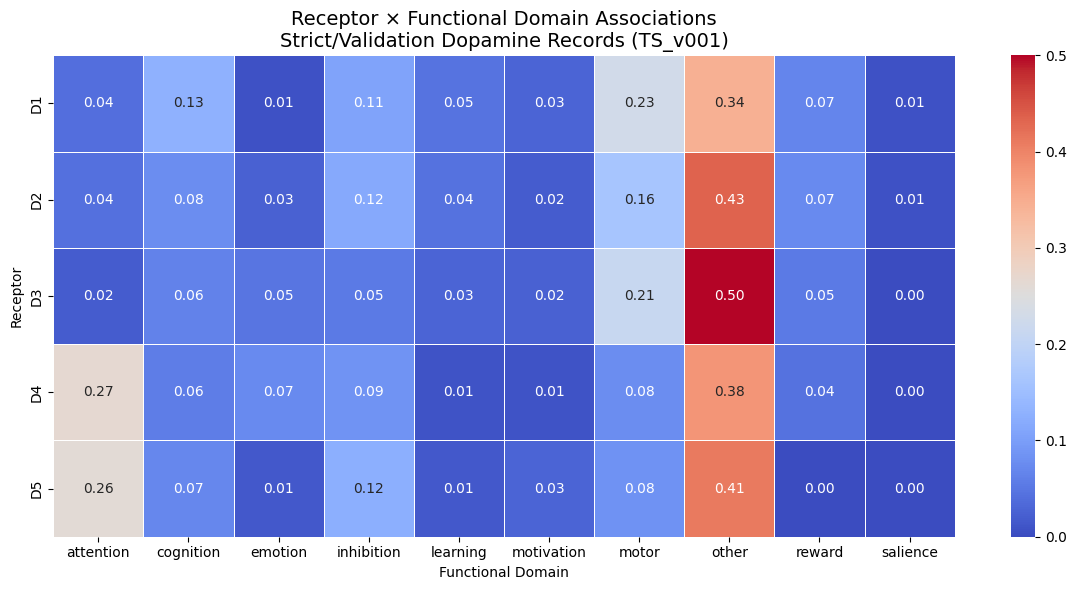


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\fig_dopamine_receptor_domain_heatmap_TS_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_domain_heatmap_values_TS_v001.csv


In [54]:
# =========================================================
# FIGURE — RECEPTOR × DOMAIN HEATMAP
# TS_v001 STRICT / VALIDATION RECORDS
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# BUILD MATRIX
# ---------------------------------------------------------

heat = (
    df_strict[
        df_strict["receptors"] != "none"
    ]
    .groupby(["receptors", "domain"])
    .size()
    .unstack(fill_value=0)
)

# ---------------------------------------------------------
# OPTIONAL:
# normalize by receptor row totals
# easier to compare receptor preferences
# ---------------------------------------------------------

heat_norm = heat.div(
    heat.sum(axis=1),
    axis=0
)

print("\n=== RAW COUNTS ===")
print(heat)

print("\n=== ROW-NORMALIZED ===")
print(
    heat_norm.round(3)
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.heatmap(
    heat_norm,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Receptor × Functional Domain Associations\nStrict/Validation Dopamine Records (TS_v001)",
    fontsize=14
)

plt.xlabel("Functional Domain")
plt.ylabel("Receptor")

plt.tight_layout()

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

OUT_PNG = (
    BASE
    / "analysis"
    / "fig_dopamine_receptor_domain_heatmap_TS_v001.png"
)

OUT_CSV = (
    BASE
    / "analysis"
    / "dopamine_receptor_domain_heatmap_values_TS_v001.csv"
)

plt.savefig(
    OUT_PNG,
    dpi=300,
    bbox_inches="tight"
)

heat_norm.to_csv(OUT_CSV)

plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_CSV)

In [55]:
# =========================================================
# LOAD TS_v001 UMAP COORDINATES
# =========================================================

import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path(r"C:\neurofeedback_models\dopamine_20251202\TS_v001")

# ---------------------------------------------------------
# LOAD MASTER
# ---------------------------------------------------------

df = pd.read_csv(
    BASE / "dopamine_TS_master_v001.csv"
)

# ---------------------------------------------------------
# LOAD UMAP
# ---------------------------------------------------------

umap_coords = np.load(
    BASE / "dopamine_umap_coords_v001.npy"
)

print("DF:", df.shape)
print("UMAP:", umap_coords.shape)

# ---------------------------------------------------------
# ATTACH COORDS
# ---------------------------------------------------------

df["umap_1"] = umap_coords[:, 0]
df["umap_2"] = umap_coords[:, 1]

# ---------------------------------------------------------
# TEXT FIELD
# ---------------------------------------------------------

df["text"] = (
    df["title"].fillna("") + " " +
    df["abstract"].fillna("")
).str.lower()

print("\nUMAP columns added.")
print(df[["umap_1", "umap_2"]].head())

DF: (157573, 10)
UMAP: (157573, 2)

UMAP columns added.
      umap_1     umap_2
0   9.625370   8.213124
1   8.802214  11.966985
2  12.086824  11.084372
3   9.909420   9.516801
4   9.352865   7.791889



=== MOTOR CENTROID ===
{'umap_1': 8.53747, 'umap_2': 10.99196}

=== RECEPTOR CENTROIDS ===
  receptor      n  centroid_x  centroid_y  distance_to_motor
4       D5    580   10.298126   10.391351           1.860280
0       D1   2851   10.255555    9.724563           2.134974
1       D2  10342   10.833062   10.233756           2.417564
2       D3   2318   11.028237   10.952958           2.491073
3       D4   1708   12.015021   11.971477           3.612868


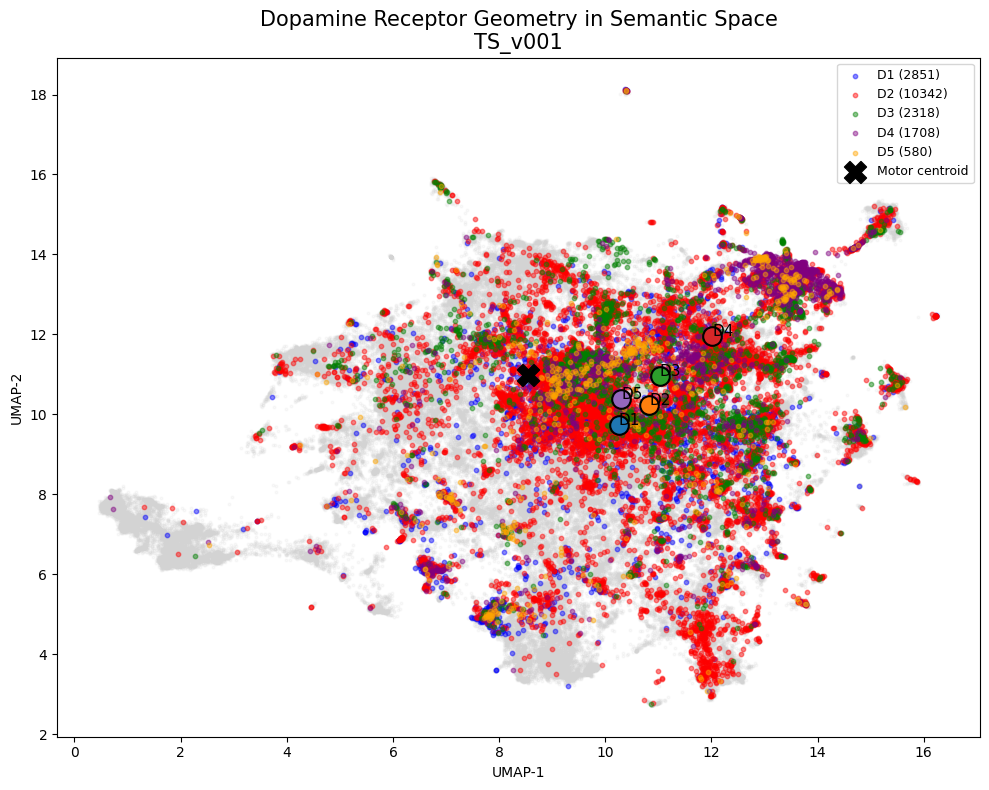


Saved:
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_umap_geometry_TS_v001.png
C:\neurofeedback_models\dopamine_20251202\TS_v001\analysis\dopamine_receptor_centroids_TS_v001.csv


In [56]:
# =========================================================
# TS_v001 — RECEPTOR GEOMETRY IN DOPAMINE SPACE
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# RECEPTOR TERMS
# ---------------------------------------------------------

receptor_patterns = {
    "D1": [
        r"\bd1 receptor\b",
        r"\bd1 receptors\b",
        r"\bdrd1\b"
    ],
    "D2": [
        r"\bd2 receptor\b",
        r"\bd2 receptors\b",
        r"\bdrd2\b"
    ],
    "D3": [
        r"\bd3 receptor\b",
        r"\bd3 receptors\b",
        r"\bdrd3\b"
    ],
    "D4": [
        r"\bd4 receptor\b",
        r"\bd4 receptors\b",
        r"\bdrd4\b"
    ],
    "D5": [
        r"\bd5 receptor\b",
        r"\bd5 receptors\b",
        r"\bdrd5\b"
    ]
}

# ---------------------------------------------------------
# ASSIGN RECEPTOR LABELS
# ---------------------------------------------------------

df["receptor"] = "none"

for rec, patterns in receptor_patterns.items():

    mask = df["text"].str.contains(
        "|".join(patterns),
        regex=True,
        na=False
    )

    df.loc[mask, "receptor"] = rec

# ---------------------------------------------------------
# MOTOR MASK
# ---------------------------------------------------------

motor_mask = (
    df["text"].str.contains(
        r"\bmotor\b|\bmovement\b|locomot|parkinson",
        regex=True,
        na=False
    )
)

motor_centroid = {
    "umap_1": df.loc[motor_mask, "umap_1"].mean(),
    "umap_2": df.loc[motor_mask, "umap_2"].mean()
}

print("\n=== MOTOR CENTROID ===")
print(motor_centroid)

# ---------------------------------------------------------
# RECEPTOR CENTROIDS
# ---------------------------------------------------------

receptor_centroids = []

for rec in ["D1", "D2", "D3", "D4", "D5"]:

    sub = df[df["receptor"] == rec]

    if len(sub) == 0:
        continue

    cx = sub["umap_1"].mean()
    cy = sub["umap_2"].mean()

    dist_motor = np.sqrt(
        (cx - motor_centroid["umap_1"])**2 +
        (cy - motor_centroid["umap_2"])**2
    )

    receptor_centroids.append({
        "receptor": rec,
        "n": len(sub),
        "centroid_x": cx,
        "centroid_y": cy,
        "distance_to_motor": dist_motor
    })

receptor_centroids = pd.DataFrame(receptor_centroids)

print("\n=== RECEPTOR CENTROIDS ===")
print(
    receptor_centroids.sort_values(
        "distance_to_motor"
    )
)

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

# background semantic space
plt.scatter(
    df["umap_1"],
    df["umap_2"],
    color="lightgray",
    alpha=0.12,
    s=4
)

# receptor colors
colors = {
    "D1": "blue",
    "D2": "red",
    "D3": "green",
    "D4": "purple",
    "D5": "orange"
}

# ---------------------------------------------------------
# RECEPTOR POINTS
# ---------------------------------------------------------

for rec, color in colors.items():

    sub = df[df["receptor"] == rec]

    plt.scatter(
        sub["umap_1"],
        sub["umap_2"],
        color=color,
        alpha=0.45,
        s=10,
        label=f"{rec} ({len(sub)})"
    )

# ---------------------------------------------------------
# MOTOR CENTROID
# ---------------------------------------------------------

plt.scatter(
    motor_centroid["umap_1"],
    motor_centroid["umap_2"],
    color="black",
    s=250,
    marker="X",
    label="Motor centroid"
)

# ---------------------------------------------------------
# RECEPTOR CENTROIDS
# ---------------------------------------------------------

for _, row in receptor_centroids.iterrows():

    plt.scatter(
        row["centroid_x"],
        row["centroid_y"],
        s=180,
        edgecolor="black",
        linewidth=1.5
    )

    plt.text(
        row["centroid_x"],
        row["centroid_y"],
        row["receptor"],
        fontsize=11
    )

# ---------------------------------------------------------
# COSMETICS
# ---------------------------------------------------------

plt.title(
    "Dopamine Receptor Geometry in Semantic Space\nTS_v001",
    fontsize=15
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    loc="best",
    fontsize=9
)

plt.tight_layout()

# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

OUT_PNG = (
    BASE
    / "analysis"
    / "dopamine_receptor_umap_geometry_TS_v001.png"
)

OUT_CSV = (
    BASE
    / "analysis"
    / "dopamine_receptor_centroids_TS_v001.csv"
)

plt.savefig(
    OUT_PNG,
    dpi=300,
    bbox_inches="tight"
)

receptor_centroids.to_csv(
    OUT_CSV,
    index=False
)

plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_CSV)